# CESM2-LE and RFMIP global annual means

Inventory all 100 CESM2 Large Ensemble members, then load global, area-weighted annual means of `FSNT`, `FLNT`, and `TREFHT` for the 50 `smbb` members used in the downstream analysis. Historical output is joined to SSP3-7.0 output at 2015. The corresponding three-member prescribed-SST RFMIP ensemble mean is loaded for 1850–2014.

CESM monthly means are timestamped at the **right endpoint** of their averaging interval: for example, the January 1850 mean has `time = 1850-02-01`, and the December 2024 mean has `time = 2025-01-01`. The calculations below therefore use the lower `time_bnds` endpoint to identify each month and use the exact bound-to-bound duration as its annual-mean weight. Spatial means use CAM's native Gaussian latitude weights, `gw`, together with the uniformly spaced longitudes.

In [8]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.auto import tqdm

DATA_ROOT = Path(
    "/glade/u/home/vcooper/work/hist_sst/"
    "bayecs/links/d651056/CESM2-LE/atm/proc/tseries/month_1"
)
RFMIP_ROOT = Path(
    "/glade/campaign/cesm/development/cvcwg/cvwg/"
    "f.e21.FHIST_BGCsmbb.f09_f09_mg17.SSTICE_CMIP6-piControl"
)
VARIABLES = ("FSNT", "FLNT", "TREFHT")
START_YEAR = 1850
END_YEAR = 2024
RFMIP_END_YEAR = 2014
EXPECTED_TOTAL_MEMBERS = 100
EXPECTED_ANALYSIS_MEMBERS = 50
EXPECTED_RFMIP_MEMBERS = 3
EXPECTED_YEARS = np.arange(START_YEAR, END_YEAR + 1)
EXPECTED_RFMIP_YEARS = np.arange(START_YEAR, RFMIP_END_YEAR + 1)

# Explicit cftime decoding preserves CESM's no-leap calendar.
TIME_DECODER = xr.coders.CFDatetimeCoder(use_cftime=True)

## Inventory the required files

Member identity is parsed from `LE2-####.###`. This is important because the archive contains both `cmip6` and `smbb` forcing variants; historical and SSP files are paired by member ID, not by their case-name prefix. The filename-period filter excludes every chunk beginning after December 2024. The downstream subset is selected explicitly with `forcing_variant == 'smbb'`, not by positional slicing, because the two variants are interleaved when member IDs are sorted.

In [9]:
FILE_RE = re.compile(
    r"^b\.e21\.(?P<experiment>[^.]+)\.f09_g17\."
    r"LE2-(?P<member>\d{4}\.\d{3})\.cam\.h0\."
    r"(?P<variable>FSNT|FLNT|TREFHT)\."
    r"(?P<start_month>\d{6})-(?P<end_month>\d{6})\.nc$"
)
FIRST_MONTH = 100 * START_YEAR + 1
LAST_MONTH = 100 * END_YEAR + 12


def build_file_catalog():
    rows = []
    for variable in VARIABLES:
        for path in sorted((DATA_ROOT / variable).glob("*.nc")):
            match = FILE_RE.match(path.name)
            if match is None:
                raise ValueError(f"Unexpected filename: {path.name}")

            item = match.groupdict()
            item["start_month"] = int(item["start_month"])
            item["end_month"] = int(item["end_month"])
            if (
                item["start_month"] <= LAST_MONTH
                and item["end_month"] >= FIRST_MONTH
            ):
                item["path"] = path
                rows.append(item)

    return (
        pd.DataFrame(rows)
        .sort_values(["variable", "member", "start_month"])
        .reset_index(drop=True)
    )


catalog = build_file_catalog()
catalog["forcing_variant"] = catalog["experiment"].str.extract(
    r"(cmip6|smbb)", expand=False
)
all_members = np.array(sorted(catalog["member"].unique()))

member_sets = {
    variable: set(catalog.loc[catalog.variable == variable, "member"])
    for variable in VARIABLES
}
assert len(all_members) == EXPECTED_TOTAL_MEMBERS
assert all(
    member_sets[variable] == set(all_members) for variable in VARIABLES
)

files_per_series = catalog.groupby(["variable", "member"]).size()
assert files_per_series.eq(18).all(), files_per_series.describe()
assert catalog.groupby("member")["forcing_variant"].nunique().eq(1).all()

# The RFMIP forcing configuration applies to these 50 members only.
smbb_catalog = catalog.loc[catalog.forcing_variant.eq("smbb")].copy()
smbb_members = np.array(sorted(smbb_catalog["member"].unique()))
assert len(smbb_members) == EXPECTED_ANALYSIS_MEMBERS
assert set(smbb_catalog.forcing_variant) == {"smbb"}
assert smbb_catalog.groupby(["variable", "member"]).size().eq(18).all()
assert smbb_catalog.groupby("variable")["member"].nunique().eq(50).all()

catalog_summary = catalog.groupby("variable").agg(
    all_members=("member", "nunique"),
    files=("path", "size"),
    first_month=("start_month", "min"),
    last_month=("end_month", "max"),
)
catalog_summary["smbb_members_used"] = smbb_catalog.groupby(
    "variable"
)["member"].nunique()
catalog_summary["smbb_files_used"] = smbb_catalog.groupby("variable").size()
catalog_summary

,all_members,files,first_month,last_month,smbb_members_used,smbb_files_used
variable,,,,,,
FLNT,100,1800,185001,202412,50,900
FSNT,100,1800,185001,202412,50,900
TREFHT,100,1800,185001,202412,50,900


## Verify the CESM time and grid conventions

The check below shows the right-end timestamps for January and December of the first year. It also verifies the `noleap` calendar, the Gaussian-weight normalization, and uniform longitude spacing before the full calculation starts.

In [10]:
example_path = catalog.iloc[0].path
with xr.open_dataset(example_path, decode_times=TIME_DECODER) as example:
    sample = np.array([0, 11])
    stored_time = example.time.isel(time=sample).values
    sample_bounds = example.time_bnds.isel(time=sample).load()
    calendar = example.time.encoding.get("calendar")

    assert calendar == "noleap"
    assert np.array_equal(stored_time, sample_bounds.isel(nbnd=1).values)
    np.testing.assert_allclose(example.gw.sum().item(), 2.0)
    longitude_step = np.diff(example.lon.values)
    np.testing.assert_allclose(longitude_step, longitude_step[0])

time_convention = pd.DataFrame(
    {
        "stored_time": [str(value) for value in stored_time],
        "interval_start": [
            str(value) for value in sample_bounds.isel(nbnd=0).values
        ],
        "interval_end": [
            str(value) for value in sample_bounds.isel(nbnd=1).values
        ],
    },
    index=["January mean", "December mean"],
)
time_convention

,stored_time,interval_start,interval_end
January mean,1850-02-01 00:00:00,1850-01-01 00:00:00,1850-02-01 00:00:00
December mean,1851-01-01 00:00:00,1850-12-01 00:00:00,1851-01-01 00:00:00


## Stream, reduce, and aggregate

Only one gridded source file is opened at a time. Each file is immediately reduced to a global monthly series and closed, keeping memory bounded. The annual means are duration weighted from `time_bnds`; they are not unweighted averages of 12 monthly values.

In [11]:
def load_member_variable(paths, variable, start_year, end_year):
    """Return one member's eager global annual mean for one variable."""
    monthly_parts = []
    duration_parts = []
    calendars = set()
    source_attrs = None

    for path in paths:
        with xr.open_dataset(path, decode_times=TIME_DECODER) as source:
            if source_attrs is None:
                source_attrs = source[variable].attrs.copy()
            calendars.add(source.time.encoding.get("calendar"))

            # Load only the tiny bounds array before doing cftime arithmetic.
            bounds = source.time_bnds.load()
            interval_start = bounds.isel(nbnd=0, drop=True)
            interval_end = bounds.isel(nbnd=1, drop=True)
            duration_days = np.fromiter(
                (
                    (end - start).days
                    for start, end in zip(
                        interval_start.values, interval_end.values
                    )
                ),
                dtype=np.float64,
                count=source.sizes["time"],
            )

            interval_year = interval_start.dt.year.values
            take = np.flatnonzero(
                (interval_year >= start_year) & (interval_year <= end_year)
            )
            if take.size == 0:
                continue

            # gw is the exact CAM Gaussian latitude weight; lon cells are uniform.
            global_month = (
                source[variable]
                .isel(time=take)
                .weighted(source.gw)
                .mean(("lat", "lon"), skipna=False)
                .load()
            )
            month_coordinate = interval_start.isel(time=take).values
            global_month = global_month.assign_coords(
                time=("time", month_coordinate)
            )
            duration = xr.DataArray(
                duration_days[take],
                dims="time",
                coords={"time": month_coordinate},
                name="interval_days",
            )
            monthly_parts.append(global_month)
            duration_parts.append(duration)

    assert calendars == {"noleap"}, calendars
    if not monthly_parts:
        raise ValueError(f"No {variable} data within {start_year}–{end_year}")

    monthly = xr.concat(monthly_parts, dim="time").sortby("time")
    duration = xr.concat(duration_parts, dim="time").sortby("time")
    assert monthly.indexes["time"].is_unique
    assert monthly.notnull().all().item()

    year = monthly.time.dt.year.rename("year")
    months_per_year = xr.ones_like(duration, dtype=np.int16).groupby(year).sum()
    days_per_year = duration.groupby(year).sum()

    expected_years = np.arange(start_year, end_year + 1)
    np.testing.assert_array_equal(months_per_year.year.values, expected_years)
    np.testing.assert_array_equal(months_per_year.values, 12)
    np.testing.assert_allclose(days_per_year.values, 365.0)

    annual = (
        (monthly * duration).groupby(year).sum(dim="time") / days_per_year
    ).rename(variable)
    annual.attrs = {
        **source_attrs,
        "long_name": (
            "Global area-weighted annual mean: "
            f"{source_attrs.get('long_name', variable)}"
        ),
        "cell_methods": (
            "lat lon: mean (area-weighted with CAM gw); "
            "time: mean (interval-weighted from time_bnds)"
        ),
    }
    return annual


def load_cesm2le_global_annual(file_catalog):
    """Load all requested variables and members into one eager Dataset."""
    selected_members = np.array(sorted(file_catalog["member"].unique()))
    member_datasets = []
    for member in tqdm(selected_members, desc="CESM2-LE smbb members"):
        member_data = {}
        for variable in VARIABLES:
            paths = file_catalog.loc[
                (file_catalog.member == member)
                & (file_catalog.variable == variable),
                "path",
            ].tolist()
            member_data[variable] = load_member_variable(
                paths, variable, START_YEAR, END_YEAR
            )

        member_datasets.append(
            xr.Dataset(member_data).expand_dims(member=[member])
        )

    result = xr.concat(member_datasets, dim="member")
    variant_by_member = (
        file_catalog[["member", "forcing_variant"]]
        .drop_duplicates()
        .set_index("member")["forcing_variant"]
    )
    result = result.assign_coords(
        forcing_variant=(
            "member",
            variant_by_member.loc[result.member.values].values,
        )
    )
    result.attrs = {
        "source": "CESM2 Large Ensemble",
        "experiments": "BHIST through 2014; SSP3-7.0 from 2015",
        "time_coverage": f"{START_YEAR}-01 through {END_YEAR}-12",
        "calendar": "noleap",
        "spatial_weighting": "CAM Gaussian latitude weights (gw); uniform longitude",
        "temporal_weighting": "monthly interval lengths from time_bnds",
    }
    return result.transpose("member", "year")

## Load the 50 `smbb` members used below

The inventory above verifies all 100 members, but the gridded data loaded from this point onward are restricted to the 50 `smbb` members to which the RFMIP forcing calculation applies. This is an I/O-heavy first pass (about 40 GiB of compressed source files), although only the reduced annual series remain in memory. The eager `xarray.Dataset` `cesm2le_annual_global` has dimensions `(member: 50, year: 175)`.

In [12]:
cesm2le_annual_global = load_cesm2le_global_annual(smbb_catalog)

assert cesm2le_annual_global.sizes == {"member": 50, "year": 175}
np.testing.assert_array_equal(cesm2le_annual_global.member.values, smbb_members)
assert set(cesm2le_annual_global.forcing_variant.values) == {"smbb"}
np.testing.assert_array_equal(cesm2le_annual_global.year.values, EXPECTED_YEARS)
assert set(cesm2le_annual_global.data_vars) == set(VARIABLES)
assert cesm2le_annual_global.to_array().notnull().all().item()
assert cesm2le_annual_global.FSNT.attrs["units"] == "W/m2"
assert cesm2le_annual_global.FLNT.attrs["units"] == "W/m2"
assert cesm2le_annual_global.TREFHT.attrs["units"] == "K"

cesm2le_annual_global

CESM2-LE smbb members:   0%|          | 0/50 [00:00<?, ?it/s]

<xarray.Dataset> Size: 212kB
Dimensions:          (member: 50, year: 175)
Coordinates:
  * member           (member) object 400B '1011.001' '1031.002' ... '1301.020'
  * year             (year) int64 1kB 1850 1851 1852 1853 ... 2022 2023 2024
    forcing_variant  (member) object 400B 'smbb' 'smbb' 'smbb' ... 'smbb' 'smbb'
Data variables:
    FSNT             (member, year) float64 70kB 239.7 240.0 ... 239.7 240.1
    FLNT             (member, year) float64 70kB 239.1 239.1 ... 238.8 238.3
    TREFHT           (member, year) float64 70kB 287.2 287.2 ... 288.5 288.7
Attributes:
    source:              CESM2 Large Ensemble
    experiments:         BHIST through 2014; SSP3-7.0 from 2015
    time_coverage:       1850-01 through 2024-12
    calendar:            noleap
    spatial_weighting:   CAM Gaussian latitude weights (gw); uniform longitude
    temporal_weighting:  monthly interval lengths from time_bnds

To avoid repeating the full source-data pass, the compact result can optionally be saved with:

```python
cesm2le_annual_global.to_netcdf("cesm2le_smbb50_global_annual_1850-2024.nc")
```

`FSNT` is net downward shortwave flux and `FLNT` is net upward longwave flux at the model top; if a net top-of-atmosphere imbalance is needed later, its CESM sign convention is `FSNT - FLNT`.

## CESM2 RFMIP prescribed-SST simulations

These experiments follow a similar protocol to the CMIP6 experiment piClim-histall that was part of CMIP6.  They are run with a prescribed monthly climatology of sea surface temperatures taken from the average of years 401 to 2000 of the CESM2 pre-industrial control.  External forcings are time varying and follow the protocols of the CMIP6 historical simulations with the exception of the prescription of biomass burning emissions during the late 20th and early 21st centuries which have been smoothed in the same way as the "smbb" members of the CESM2 large ensemble (i.e., the second 50 members).  See the "Modifications incorporated in the second half of the LENS2 simulations" section here.   The ensemble consists of three members that extend from 1850 to 2014 and the atmosphere and land for members 1 to 3 were initialized from years 1231, 1251, and 1281 of the CESM2 pre-industrial control, respectively.  This simulation can be used to diagnose the effective radiative forcing for the second 50 members of the CESM2 large ensemble and to look at the direct impact of radiative forcings, absent SST changes, more generally.

We kindly ask that you acknowledge the CVCWG when presenting results based on the CESM2 RFMIP Simulations in either oral and written form. https://www.cesm.ucar.edu/working-groups/climate/simulations/cesm2-rfmip

In [13]:
RFMIP_CASE = "f.e21.FHIST_BGCsmbb.f09_f09_mg17.SSTICE_CMIP6-piControl"
RFMIP_FILE_RE = re.compile(
    rf"^{re.escape(RFMIP_CASE)}\.(?P<member>\d{{3}})\.cam\.h0\."
    r"(?P<variable>FSNT|FLNT|TREFHT)\."
    r"(?P<start_month>\d{6})-(?P<end_month>\d{6})\.nc$"
)


def build_rfmip_catalog():
    rows = []
    case_glob = f"{RFMIP_CASE}.[0-9][0-9][0-9]"
    for case_dir in sorted(RFMIP_ROOT.glob(case_glob)):
        monthly_root = case_dir / "atm/proc/tseries/month_1"
        for variable in VARIABLES:
            for path in sorted(
                monthly_root.glob(f"*.cam.h0.{variable}.*.nc")
            ):
                match = RFMIP_FILE_RE.match(path.name)
                if match is None:
                    raise ValueError(f"Unexpected RFMIP filename: {path.name}")

                item = match.groupdict()
                item["start_month"] = int(item["start_month"])
                item["end_month"] = int(item["end_month"])
                if (
                    item["start_month"] <= 100 * RFMIP_END_YEAR + 12
                    and item["end_month"] >= FIRST_MONTH
                ):
                    item["path"] = path
                    rows.append(item)

    return (
        pd.DataFrame(rows)
        .sort_values(["variable", "member", "start_month"])
        .reset_index(drop=True)
    )


rfmip_catalog = build_rfmip_catalog()
rfmip_members = np.array(sorted(rfmip_catalog["member"].unique()))
np.testing.assert_array_equal(rfmip_members, ["001", "002", "003"])
assert len(rfmip_members) == EXPECTED_RFMIP_MEMBERS
assert rfmip_catalog.groupby(["variable", "member"]).size().eq(4).all()
assert rfmip_catalog.start_month.min() == 185001
assert rfmip_catalog.end_month.max() == 201412

# Confirm the documented atmosphere initial-condition years from file metadata.
initial_year = {}
for member in rfmip_members:
    path = rfmip_catalog.loc[
        (rfmip_catalog.member == member)
        & (rfmip_catalog.variable == VARIABLES[0]),
        "path",
    ].iloc[0]
    with xr.open_dataset(path, decode_times=False) as source:
        match = re.search(r"\.(\d{4})-01-01-00000\.nc$", source.initial_file)
        if match is None:
            raise ValueError(f"Could not parse initial_file in {path.name}")
        initial_year[member] = int(match.group(1))
assert initial_year == {"001": 1231, "002": 1251, "003": 1281}

rfmip_catalog.groupby("variable").agg(
    members=("member", "nunique"),
    files=("path", "size"),
    first_month=("start_month", "min"),
    last_month=("end_month", "max"),
)

,members,files,first_month,last_month
variable,,,,
FLNT,3,12,185001,201412
FSNT,3,12,185001,201412
TREFHT,3,12,185001,201412


In [14]:
def load_rfmip_ensemble_mean(file_catalog):
    """Load three RFMIP members and return only their equal-weight mean."""
    selected_members = np.array(sorted(file_catalog["member"].unique()))
    member_datasets = []
    for member in tqdm(selected_members, desc="RFMIP members"):
        member_data = {}
        for variable in VARIABLES:
            paths = file_catalog.loc[
                (file_catalog.member == member)
                & (file_catalog.variable == variable),
                "path",
            ].tolist()
            member_data[variable] = load_member_variable(
                paths, variable, START_YEAR, RFMIP_END_YEAR
            )
        member_datasets.append(
            xr.Dataset(member_data).expand_dims(rfmip_member=[member])
        )

    members_loaded = xr.concat(member_datasets, dim="rfmip_member")
    result = members_loaded.mean(dim="rfmip_member", keep_attrs=True)
    result.attrs = {
        "source": "CESM2 RFMIP prescribed-SST simulations",
        "experiment": RFMIP_CASE,
        "ensemble_statistic": "equal-weight mean of members 001, 002, and 003",
        "ensemble_size": EXPECTED_RFMIP_MEMBERS,
        "time_coverage": f"{START_YEAR}-01 through {RFMIP_END_YEAR}-12",
        "calendar": "noleap",
        "spatial_weighting": "CAM Gaussian latitude weights (gw); uniform longitude",
        "temporal_weighting": "monthly interval lengths from time_bnds",
    }
    return result.transpose("year")

In [15]:
rfmip_annual_global = load_rfmip_ensemble_mean(rfmip_catalog)

assert rfmip_annual_global.sizes == {"year": 165}
assert "rfmip_member" not in rfmip_annual_global.dims
assert "rfmip_member" not in rfmip_annual_global.coords
np.testing.assert_array_equal(
    rfmip_annual_global.year.values, EXPECTED_RFMIP_YEARS
)
assert set(rfmip_annual_global.data_vars) == set(VARIABLES)
assert rfmip_annual_global.to_array().notnull().all().item()
assert rfmip_annual_global.FSNT.attrs["units"] == "W/m2"
assert rfmip_annual_global.FLNT.attrs["units"] == "W/m2"
assert rfmip_annual_global.TREFHT.attrs["units"] == "K"

rfmip_annual_global

RFMIP members:   0%|          | 0/3 [00:00<?, ?it/s]

<xarray.Dataset> Size: 5kB
Dimensions:  (year: 165)
Coordinates:
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
Data variables:
    FSNT     (year) float64 1kB 240.0 240.1 240.0 239.7 ... 239.3 239.3 239.2
    FLNT     (year) float64 1kB 239.4 239.5 239.3 239.1 ... 236.7 236.5 236.5
    TREFHT   (year) float64 1kB 287.3 287.4 287.3 287.3 ... 287.5 287.4 287.4
Attributes:
    source:              CESM2 RFMIP prescribed-SST simulations
    experiment:          f.e21.FHIST_BGCsmbb.f09_f09_mg17.SSTICE_CMIP6-piControl
    ensemble_statistic:  equal-weight mean of members 001, 002, and 003
    ensemble_size:       3
    time_coverage:       1850-01 through 2014-12
    calendar:            noleap
    spatial_weighting:   CAM Gaussian latitude weights (gw); uniform longitude
    temporal_weighting:  monthly interval lengths from time_bnds

## Analysis scope from this point onward

`cesm2le_annual_global` contains only the 50 `smbb` CESM2-LE members. Because `rfmip_annual_global` ends in 2014, comparisons with RFMIP should use the explicitly aligned `cesm2le_rfmip_period` object below (1850–2014) rather than silently relying on xarray's automatic inner alignment.

In [16]:
cesm2le_rfmip_period = cesm2le_annual_global.sel(year=EXPECTED_RFMIP_YEARS)
assert cesm2le_rfmip_period.sizes == {"member": 50, "year": 165}
np.testing.assert_array_equal(
    cesm2le_rfmip_period.year.values, rfmip_annual_global.year.values
)
cesm2le_rfmip_period

<xarray.Dataset> Size: 200kB
Dimensions:          (member: 50, year: 165)
Coordinates:
  * member           (member) object 400B '1011.001' '1031.002' ... '1301.020'
  * year             (year) int64 1kB 1850 1851 1852 1853 ... 2012 2013 2014
    forcing_variant  (member) object 400B 'smbb' 'smbb' 'smbb' ... 'smbb' 'smbb'
Data variables:
    FSNT             (member, year) float64 66kB 239.7 240.0 ... 239.2 240.0
    FLNT             (member, year) float64 66kB 239.1 239.1 ... 238.1 238.5
    TREFHT           (member, year) float64 66kB 287.2 287.2 ... 288.2 288.5
Attributes:
    source:              CESM2 Large Ensemble
    experiments:         BHIST through 2014; SSP3-7.0 from 2015
    time_coverage:       1850-01 through 2024-12
    calendar:            noleap
    spatial_weighting:   CAM Gaussian latitude weights (gw); uniform longitude
    temporal_weighting:  monthly interval lengths from time_bnds

## TOA imbalance, anomalies, and radiative response

`RESTOM = FSNT - FLNT` is the net downward top-of-atmosphere radiative flux and is identified with $N$. All four annual series (`FSNT`, `FLNT`, `TREFHT`, and `RESTOM`) are converted to anomalies by subtracting their own inclusive 1850–1900 means. The reference mean is calculated separately for every CESM2-LE member; the RFMIP reference mean is calculated from the already-formed three-member ensemble mean.

Over the common 1850–2014 interval, we use the RFMIP `RESTOM` anomaly as an estimate of $F$ and define $R = N - F$, so that $N = F + R = F + \lambda T$. Under this plus-sign convention, a stabilizing climate feedback has $\lambda < 0$; $R$ is the negative of the alternative response convention $F-N$ sometimes used with a positive feedback parameter. The prescribed-SST RFMIP imbalance is an effective-forcing proxy that includes rapid adjustments and residual variability, rather than an exact noise-free $F$.

In [17]:
BASELINE_START_YEAR = 1850
BASELINE_END_YEAR = 1900
BASELINE_YEARS = np.arange(BASELINE_START_YEAR, BASELINE_END_YEAR + 1)
BASELINE_LABEL = f"{BASELINE_START_YEAR}-{BASELINE_END_YEAR} inclusive mean"


def add_restom(dataset):
    """Add net downward TOA flux while retaining the input variables."""
    fsnt_units = dataset["FSNT"].attrs.get("units")
    flnt_units = dataset["FLNT"].attrs.get("units")
    if fsnt_units != flnt_units:
        raise ValueError(
            f"FSNT and FLNT units differ: {fsnt_units!r} versus {flnt_units!r}"
        )
    restom = (dataset["FSNT"] - dataset["FLNT"]).rename("RESTOM")
    restom.attrs = {
        "long_name": "Net downward radiative flux at the top of atmosphere",
        "units": fsnt_units,
        "positive": "down",
        "calculation": "FSNT - FLNT",
    }
    result = dataset.assign(RESTOM=restom)
    result.attrs = dict(dataset.attrs)
    return result


def anomalies_from_1850_1900(dataset):
    """Subtract the inclusive 1850-1900 mean along year only."""
    reference = dataset.sel(
        year=slice(BASELINE_START_YEAR, BASELINE_END_YEAR)
    )
    np.testing.assert_array_equal(reference.year.values, BASELINE_YEARS)

    climatology = reference.mean(dim="year", keep_attrs=True)
    anomalies = dataset - climatology
    anomalies.attrs = {
        **dataset.attrs,
        "anomaly_reference_period": BASELINE_LABEL,
    }
    for variable in anomalies.data_vars:
        original_attrs = dataset[variable].attrs
        anomalies[variable].attrs = {
            **original_attrs,
            "long_name": f"{original_attrs.get('long_name', variable)} anomaly",
            "anomaly_reference_period": BASELINE_LABEL,
        }

    baseline_check = anomalies.sel(year=BASELINE_YEARS).mean(dim="year")
    np.testing.assert_allclose(
        baseline_check.to_array().values, 0.0, rtol=0.0, atol=1e-10
    )
    return anomalies, climatology


cesm2le_timeseries = add_restom(cesm2le_annual_global)
rfmip_timeseries = add_restom(rfmip_annual_global)

cesm2le_anomalies, cesm2le_climatology_1850_1900 = (
    anomalies_from_1850_1900(cesm2le_timeseries)
)
rfmip_anomalies, rfmip_climatology_1850_1900 = (
    anomalies_from_1850_1900(rfmip_timeseries)
)

assert set(cesm2le_anomalies.data_vars) == {*VARIABLES, "RESTOM"}
assert set(rfmip_anomalies.data_vars) == {*VARIABLES, "RESTOM"}
for anomaly_dataset in (cesm2le_anomalies, rfmip_anomalies):
    xr.testing.assert_allclose(
        anomaly_dataset["RESTOM"],
        (anomaly_dataset["FSNT"] - anomaly_dataset["FLNT"]).rename("RESTOM"),
    )
cesm2le_anomalies

<xarray.Dataset> Size: 282kB
Dimensions:          (member: 50, year: 175)
Coordinates:
  * member           (member) object 400B '1011.001' '1031.002' ... '1301.020'
  * year             (year) int64 1kB 1850 1851 1852 1853 ... 2022 2023 2024
    forcing_variant  (member) object 400B 'smbb' 'smbb' 'smbb' ... 'smbb' 'smbb'
Data variables:
    FSNT             (member, year) float64 70kB 0.5374 0.8712 ... 0.5064 0.9042
    FLNT             (member, year) float64 70kB -0.03929 0.03291 ... -0.8904
    TREFHT           (member, year) float64 70kB -0.04342 -0.02433 ... 1.445
    RESTOM           (member, year) float64 70kB 0.5767 0.8383 ... 0.9058 1.795
Attributes:
    source:                    CESM2 Large Ensemble
    experiments:               BHIST through 2014; SSP3-7.0 from 2015
    time_coverage:             1850-01 through 2024-12
    calendar:                  noleap
    spatial_weighting:         CAM Gaussian latitude weights (gw); uniform lo...
    temporal_weighting:        monthly interval lengths from time_bnds
    anomaly_reference_period:  1850-1900 inclusive mean

In [18]:
# Restrict N to the RFMIP years before subtraction; exact alignment prevents
# an accidental change in the comparison period. F broadcasts over member.
RESTOM_LE, RESTOM_RFMIP = xr.align(
    cesm2le_anomalies["RESTOM"].sel(year=EXPECTED_RFMIP_YEARS),
    rfmip_anomalies["RESTOM"],
    join="exact",
)

N = RESTOM_LE.rename("N")
F = RESTOM_RFMIP.rename("F")
T = cesm2le_anomalies["TREFHT"].sel(year=EXPECTED_RFMIP_YEARS).rename("T")
R = (N - F).rename("R").transpose("member", "year")

N.attrs = {
    **RESTOM_LE.attrs,
    "long_name": "CESM2-LE net TOA imbalance anomaly (N)",
}
F.attrs = {
    **RESTOM_RFMIP.attrs,
    "long_name": "RFMIP ensemble-mean RESTOM anomaly used as forcing (F)",
}
T.attrs = {
    **T.attrs,
    "long_name": "CESM2-LE global-mean surface-air temperature anomaly (T)",
}
R.attrs = {
    "long_name": "Radiative response anomaly (R = N - F)",
    "units": "W/m2",
    "calculation": "RESTOM_LE anomaly - RESTOM_RFMIP anomaly",
    "sign_convention": "N = F + R = F + lambda*T",
    "interpretation": "RFMIP RESTOM is used as an effective-forcing proxy",
    "anomaly_reference_period": BASELINE_LABEL,
}

energy_budget_terms = xr.Dataset({"N": N, "F": F, "R": R, "T": T})
energy_budget_terms.attrs = {
    "equation": "N = F + R = F + lambda*T",
    "anomaly_reference_period": BASELINE_LABEL,
    "time_coverage": "1850-2014",
}

assert R.sizes == {
    "member": EXPECTED_ANALYSIS_MEMBERS,
    "year": len(EXPECTED_RFMIP_YEARS),
}
assert F.sizes == {"year": len(EXPECTED_RFMIP_YEARS)}
np.testing.assert_array_equal(R.year.values, EXPECTED_RFMIP_YEARS)
xr.testing.assert_allclose(N, R + F)
np.testing.assert_allclose(
    R.sel(year=BASELINE_YEARS).mean(dim="year").values,
    0.0,
    rtol=0.0,
    atol=1e-10,
)
assert energy_budget_terms.to_array().notnull().all().item()

energy_budget_terms

<xarray.Dataset> Size: 201kB
Dimensions:          (member: 50, year: 165)
Coordinates:
  * member           (member) object 400B '1011.001' '1031.002' ... '1301.020'
  * year             (year) int64 1kB 1850 1851 1852 1853 ... 2012 2013 2014
    forcing_variant  (member) object 400B 'smbb' 'smbb' 'smbb' ... 'smbb' 'smbb'
Data variables:
    N                (member, year) float64 66kB 0.5767 0.8383 ... 1.112 1.436
    F                (year) float64 1kB -0.04805 -0.0763 0.05877 ... 2.152 1.981
    R                (member, year) float64 66kB 0.6248 0.9146 ... -0.5445
    T                (member, year) float64 66kB -0.04342 -0.02433 ... 1.228
Attributes:
    equation:                  N = F + R = F + lambda*T
    anomaly_reference_period:  1850-1900 inclusive mean
    time_coverage:             1850-2014

## Feedback estimates

Two signed feedback estimates are calculated for every CESM2-LE member. The period-mean estimate is $\Delta R / \Delta T$, where each change is the 1994–2014 mean minus the 1850–1900 mean. The trend estimate fits an ordinary least-squares line with an intercept to each annual time series over 1994–2014, then evaluates

$$\lambda_{\mathrm{trend}} = \frac{dN/dt - dF/dt}{dT/dt}. $$

The RFMIP-derived $dF/dt$ is common to all members. Both estimates follow the earlier convention $N=F+\lambda T$, so a stabilizing feedback is normally negative. A small member-specific temperature change or trend can make either ratio unstable; the component changes and trends are retained below so such cases can be diagnosed rather than silently discarded. The three-member RFMIP mean is treated as fixed here, so its sampling uncertainty is not propagated into either estimate.

In [19]:
LATE_START_YEAR = 1994
LATE_END_YEAR = 2014
LATE_YEARS = np.arange(LATE_START_YEAR, LATE_END_YEAR + 1)
FEEDBACK_UNITS = "W m-2 K-1"


def mean_over_years(data, years):
    """Mean over an explicit, complete set of annual values."""
    selected = data.sel(year=years)
    np.testing.assert_array_equal(selected.year.values, years)
    return selected.mean(dim="year", keep_attrs=True)


def linear_time_slope(data, years):
    """OLS slope against calendar year, including an intercept."""
    selected = data.sel(year=years)
    np.testing.assert_array_equal(selected.year.values, years)
    time = xr.DataArray(
        selected.year.values.astype(np.float64),
        dims="year",
        coords={"year": selected.year.values},
    )
    time_centered = time - time.mean(dim="year")
    data_centered = selected - selected.mean(dim="year")
    return (data_centered * time_centered).sum(dim="year") / (
        time_centered**2
    ).sum(dim="year")


R_early_mean = mean_over_years(R, BASELINE_YEARS).rename("R_early_mean")
R_late_mean = mean_over_years(R, LATE_YEARS).rename("R_late_mean")
T_early_mean = mean_over_years(T, BASELINE_YEARS).rename("T_early_mean")
T_late_mean = mean_over_years(T, LATE_YEARS).rename("T_late_mean")

delta_R = (R_late_mean - R_early_mean).rename("delta_R")
delta_T = (T_late_mean - T_early_mean).rename("delta_T")
if (delta_T == 0).any().item():
    raise ZeroDivisionError("At least one member has zero Delta T")
lambda_period_means = (delta_R / delta_T).rename("lambda_period_means")

dN_dt = linear_time_slope(N, LATE_YEARS).rename("dN_dt")
dF_dt = linear_time_slope(F, LATE_YEARS).rename("dF_dt")
dT_dt = linear_time_slope(T, LATE_YEARS).rename("dT_dt")
dR_dt = (dN_dt - dF_dt).rename("dR_dt")
if (dT_dt == 0).any().item():
    raise ZeroDivisionError("At least one member has zero dT/dt")
lambda_regression = (dR_dt / dT_dt).rename("lambda_regression")

delta_R.attrs = {"long_name": "1994-2014 mean R minus 1850-1900 mean R", "units": "W/m2"}
delta_T.attrs = {"long_name": "1994-2014 mean T minus 1850-1900 mean T", "units": "K"}
lambda_period_means.attrs = {
    "long_name": "Feedback from the ratio of period-mean changes",
    "units": FEEDBACK_UNITS,
    "calculation": "Delta R / Delta T",
    "early_period": "1850-1900 inclusive",
    "late_period": "1994-2014 inclusive",
}
dN_dt.attrs = {"long_name": "OLS time trend in N, 1994-2014", "units": "W m-2 yr-1"}
dF_dt.attrs = {"long_name": "OLS time trend in F, 1994-2014", "units": "W m-2 yr-1"}
dR_dt.attrs = {"long_name": "dN/dt minus dF/dt, 1994-2014", "units": "W m-2 yr-1"}
dT_dt.attrs = {"long_name": "OLS time trend in T, 1994-2014", "units": "K yr-1"}
lambda_regression.attrs = {
    "long_name": "Feedback from the ratio of OLS time trends",
    "units": FEEDBACK_UNITS,
    "calculation": "(dN/dt - dF/dt) / (dT/dt)",
    "regression_period": "1994-2014 inclusive",
}

feedback_estimates = xr.Dataset(
    {
        "lambda_period_means": lambda_period_means,
        "lambda_regression": lambda_regression,
        "delta_R": delta_R,
        "delta_T": delta_T,
        "dN_dt": dN_dt,
        "dF_dt": dF_dt,
        "dR_dt": dR_dt,
        "dT_dt": dT_dt,
    }
)
feedback_estimates.attrs = {
    "sign_convention": "N = F + R = F + lambda*T",
    "finite_difference_periods": "1850-1900 to 1994-2014",
    "trend_period": "1994-2014",
}

assert feedback_estimates.sizes == {"member": EXPECTED_ANALYSIS_MEMBERS}
np.testing.assert_allclose(
    dR_dt.values,
    linear_time_slope(R, LATE_YEARS).values,
    rtol=1e-12,
    atol=1e-12,
)
for estimate in (lambda_period_means, lambda_regression):
    assert np.isfinite(estimate.values).all()

feedback_estimates

<xarray.Dataset> Size: 4kB
Dimensions:              (member: 50)
Coordinates:
  * member               (member) object 400B '1011.001' ... '1301.020'
    forcing_variant      (member) object 400B 'smbb' 'smbb' ... 'smbb' 'smbb'
Data variables:
    lambda_period_means  (member) float64 400B -1.078 -1.28 ... -1.27 -1.153
    lambda_regression    (member) float64 400B -1.388 -1.08 ... -3.189 -1.459
    delta_R              (member) float64 400B -0.9062 -0.9118 ... -1.037 -0.984
    delta_T              (member) float64 400B 0.8403 0.7122 ... 0.8162 0.8534
    dN_dt                (member) float64 400B -0.0003605 0.01722 ... 0.01759
    dF_dt                float64 8B 0.05582
    dR_dt                (member) float64 400B -0.05618 -0.0386 ... -0.03823
    dT_dt                (member) float64 400B 0.04048 0.03574 ... 0.0262
Attributes:
    sign_convention:            N = F + R = F + lambda*T
    finite_difference_periods:  1850-1900 to 1994-2014
    trend_period:               1994-2014

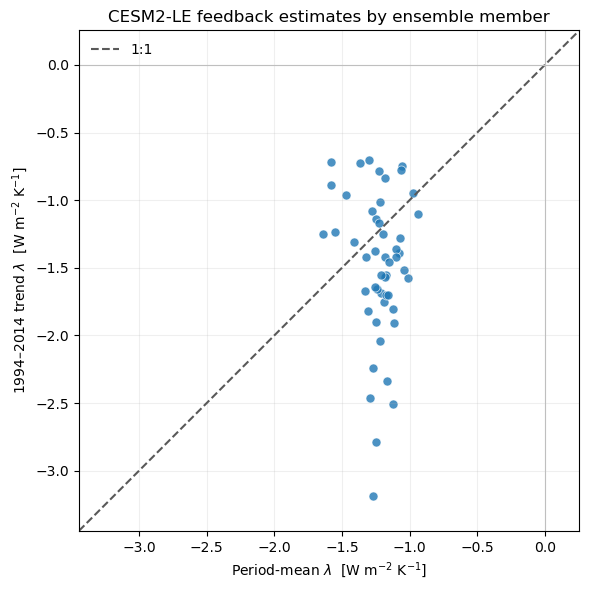

In [20]:
x = feedback_estimates["lambda_period_means"]
y = feedback_estimates["lambda_regression"]
plot_values = np.concatenate([x.values, y.values])
plot_min = min(float(plot_values.min()), 0.0)
plot_max = max(float(plot_values.max()), 0.0)
plot_span = plot_max - plot_min
plot_padding = 0.08 * plot_span if plot_span > 0 else 0.1
plot_limits = (plot_min - plot_padding, plot_max + plot_padding)

fig, ax = plt.subplots(figsize=(6.5, 6.0))
ax.scatter(
    x,
    y,
    s=42,
    alpha=0.8,
    color="tab:blue",
    edgecolor="white",
    linewidth=0.5,
)
ax.plot(plot_limits, plot_limits, color="0.35", linestyle="--", label="1:1")
ax.axhline(0.0, color="0.75", linewidth=0.8)
ax.axvline(0.0, color="0.75", linewidth=0.8)
ax.set_xlim(plot_limits)
ax.set_ylim(plot_limits)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Period-mean $\lambda$  [W m$^{-2}$ K$^{-1}$]")
ax.set_ylabel("1994–2014 trend $\lambda$  [W m$^{-2}$ K$^{-1}$]")
ax.set_title("CESM2-LE feedback estimates by ensemble member")
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

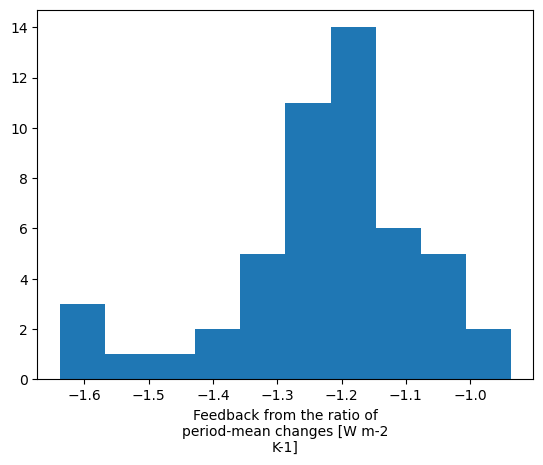

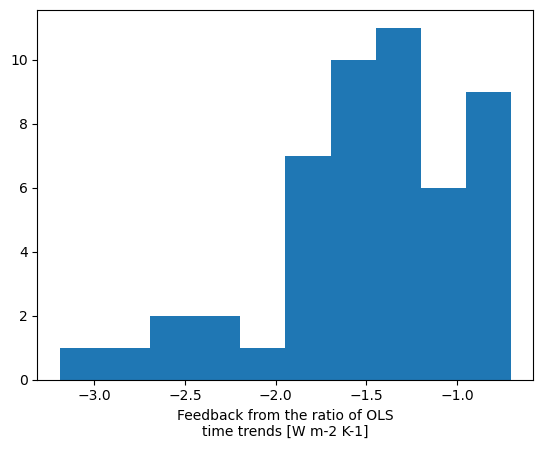

In [21]:
x.plot.hist()
plt.show()

y.plot.hist()
plt.show()

## Initialization structure of the selected 50 members

The selected `smbb` subset contains **10 standalone macro-initialization members**, initialized from preindustrial-control years 1011, 1031, …, 1191. The other **40 members** are atmospheric micro perturbations arranged as four groups of 10 that share macro initial-condition backgrounds from years 1231, 1251, 1281, and 1301. Thus, the selected subset contains **14 distinct preindustrial-control restart states** (10 standalone plus 4 shared backgrounds), but only 10 of the 50 members are classified as standalone macro runs. This follows the [official CESM2-LENS2 initialization design](https://www.cesm.ucar.edu/community-projects/lens2) and [Rodgers et al. (2021), Section 2.2](https://esd.copernicus.org/articles/12/1393/2021/).

The members—especially those within a shared micro-perturbation cluster—should not be treated as fully independent immediately after initialization. This matters for the period-mean feedback estimate because its early reference period is 1850–1900; the 1994–2014 trend estimate is much farther removed from initialization.

## Feedback-ratio diagnostics and initialization sensitivity

The first two plots expose the numerator and denominator of the short-period trend ratio. The final figure compares the original 50 member-level estimates with two initialization-aware sensitivity samples. For the 14-state sample, the underlying annual `N`, `R`, and `T` series are averaged within each shared micro-perturbation cluster *before* either feedback ratio is recalculated; member-level ratios are not averaged. Pearson correlations shown in the panels are descriptive and are not treated as ordinary independent-member significance tests.

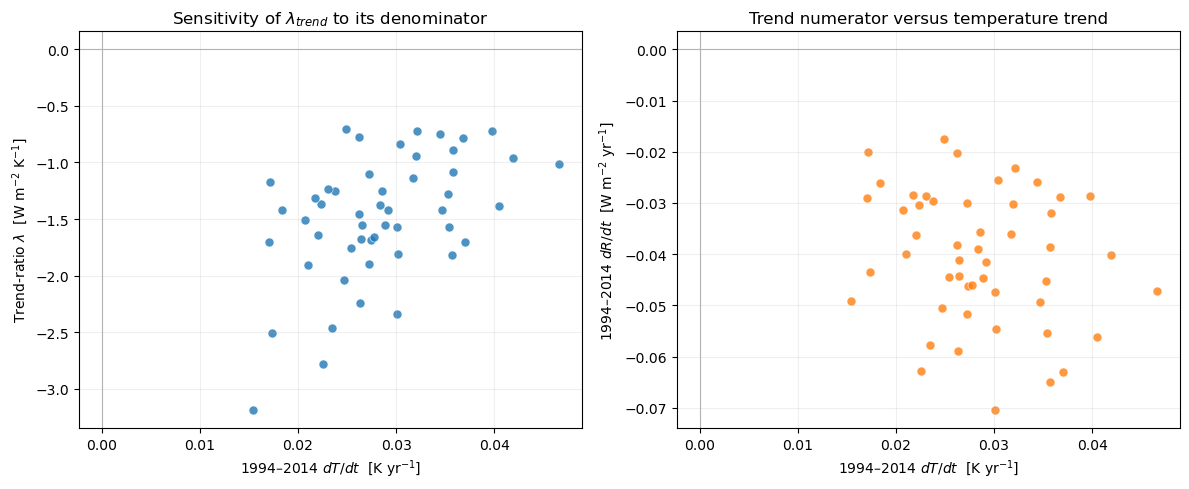

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0))

axes[0].scatter(
    dT_dt,
    lambda_regression,
    s=42,
    alpha=0.8,
    color="tab:blue",
    edgecolor="white",
    linewidth=0.5,
)
axes[0].axhline(0.0, color="0.7", linewidth=0.8)
axes[0].axvline(0.0, color="0.7", linewidth=0.8)
axes[0].set_xlabel("1994–2014 $dT/dt$  [K yr$^{-1}$]")
axes[0].set_ylabel("Trend-ratio $\lambda$  [W m$^{-2}$ K$^{-1}$]")
axes[0].set_title("Sensitivity of $\lambda_{trend}$ to its denominator")
axes[0].grid(alpha=0.2)

axes[1].scatter(
    dT_dt,
    dR_dt,
    s=42,
    alpha=0.8,
    color="tab:orange",
    edgecolor="white",
    linewidth=0.5,
)
axes[1].axhline(0.0, color="0.7", linewidth=0.8)
axes[1].axvline(0.0, color="0.7", linewidth=0.8)
axes[1].set_xlabel("1994–2014 $dT/dt$  [K yr$^{-1}$]")
axes[1].set_ylabel("1994–2014 $dR/dt$  [W m$^{-2}$ yr$^{-1}$]")
axes[1].set_title("Trend numerator versus temperature trend")
axes[1].grid(alpha=0.2)

fig.tight_layout()
plt.show()

In [23]:
STANDALONE_MACRO_YEARS = np.arange(1011, 1192, 20)
MICRO_CLUSTER_YEARS = np.array([1231, 1251, 1281, 1301])
EXPECTED_MACRO_STATES = np.concatenate(
    [STANDALONE_MACRO_YEARS, MICRO_CLUSTER_YEARS]
)


def member_branch_year(member_id):
    match = re.fullmatch(r"(?P<branch_year>\d{4})\.\d{3}", str(member_id))
    if match is None:
        raise ValueError(f"Unexpected CESM2-LE member ID: {member_id!r}")
    return int(match.group("branch_year"))


member_ids = N.member.values.astype(str)
branch_years = np.array([member_branch_year(member) for member in member_ids])
standalone_mask = np.isin(branch_years, STANDALONE_MACRO_YEARS)
micro_mask = np.isin(branch_years, MICRO_CLUSTER_YEARS)

np.testing.assert_array_equal(np.unique(branch_years), EXPECTED_MACRO_STATES)
assert standalone_mask.sum() == 10
assert micro_mask.sum() == 40
assert np.all(standalone_mask | micro_mask)
for branch_year in MICRO_CLUSTER_YEARS:
    assert np.count_nonzero(branch_years == branch_year) == 10

member_initialization = xr.Dataset(
    {
        "initialization_type": (
            "member",
            np.where(standalone_mask, "standalone_macro", "micro"),
        )
    },
    coords={
        "member": N.member.values,
        "macro_state": ("member", branch_years),
    },
)
standalone_members = member_ids[standalone_mask]


def average_by_macro_state(data):
    return (
        data.assign_coords(macro_state=("member", branch_years))
        .groupby("macro_state")
        .mean(dim="member", keep_attrs=True)
        .transpose("macro_state", "year")
    )


N_macro_state = average_by_macro_state(N).rename("N")
R_macro_state = average_by_macro_state(R).rename("R")
T_macro_state = average_by_macro_state(T).rename("T")
assert N_macro_state.sizes == {"macro_state": 14, "year": 165}
np.testing.assert_allclose(
    R_macro_state.values,
    (N_macro_state - F).transpose("macro_state", "year").values,
    rtol=1e-12,
    atol=1e-12,
)

macro_delta_R = (
    mean_over_years(R_macro_state, LATE_YEARS)
    - mean_over_years(R_macro_state, BASELINE_YEARS)
).rename("delta_R")
macro_delta_T = (
    mean_over_years(T_macro_state, LATE_YEARS)
    - mean_over_years(T_macro_state, BASELINE_YEARS)
).rename("delta_T")
macro_dN_dt = linear_time_slope(N_macro_state, LATE_YEARS).rename("dN_dt")
macro_dT_dt = linear_time_slope(T_macro_state, LATE_YEARS).rename("dT_dt")

if (macro_delta_T == 0).any().item() or (macro_dT_dt == 0).any().item():
    raise ZeroDivisionError(
        "At least one macro-state summary has a zero temperature denominator"
    )

macro_state_feedback = xr.Dataset(
    {
        "lambda_period_means": (macro_delta_R / macro_delta_T).rename(
            "lambda_period_means"
        ),
        "lambda_regression": (
            (macro_dN_dt - dF_dt) / macro_dT_dt
        ).rename("lambda_regression"),
        "delta_R": macro_delta_R,
        "delta_T": macro_delta_T,
        "dN_dt": macro_dN_dt,
        "dF_dt": dF_dt,
        "dR_dt": (macro_dN_dt - dF_dt).rename("dR_dt"),
        "dT_dt": macro_dT_dt,
    }
)
macro_state_feedback.attrs = {
    "description": "Feedback estimates for 14 distinct control-run initialization states",
    "aggregation": "Annual time series averaged within macro state before ratios",
}
assert macro_state_feedback.sizes == {"macro_state": 14}
assert macro_state_feedback.to_array().notnull().all().item()

standalone_macro_feedback = feedback_estimates.sel(member=standalone_members)
assert standalone_macro_feedback.sizes == {"member": 10}

macro_state_feedback

<xarray.Dataset> Size: 904B
Dimensions:              (macro_state: 14)
Coordinates:
  * macro_state          (macro_state) int64 112B 1011 1031 1051 ... 1281 1301
Data variables:
    lambda_period_means  (macro_state) float64 112B -1.078 -1.28 ... -1.139
    lambda_regression    (macro_state) float64 112B -1.388 -1.08 ... -1.68
    delta_R              (macro_state) float64 112B -0.9062 -0.9118 ... -0.951
    delta_T              (macro_state) float64 112B 0.8403 0.7122 ... 0.8349
    dN_dt                (macro_state) float64 112B -0.0003605 ... 0.01393
    dF_dt                float64 8B 0.05582
    dR_dt                (macro_state) float64 112B -0.05618 ... -0.04189
    dT_dt                (macro_state) float64 112B 0.04048 0.03574 ... 0.02493
Attributes:
    description:  Feedback estimates for 14 distinct control-run initializati...
    aggregation:  Annual time series averaged within macro state before ratios

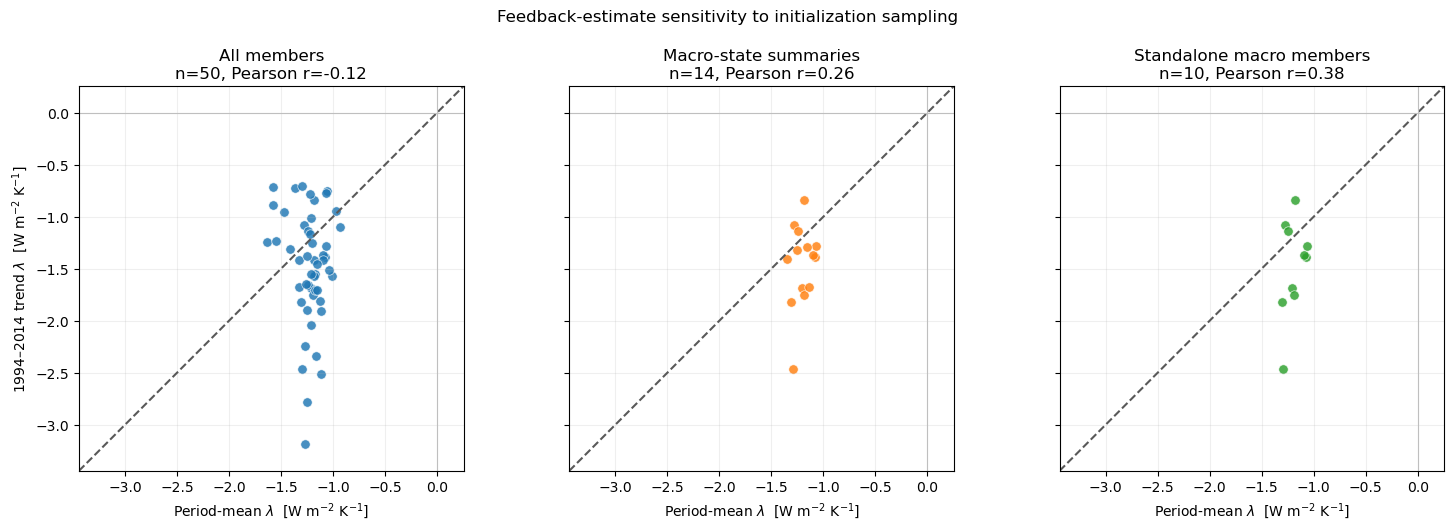

In [24]:
def pearson_correlation(x_values, y_values):
    return float(np.corrcoef(x_values.values, y_values.values)[0, 1])


sensitivity_samples = [
    ("All members", feedback_estimates, "tab:blue"),
    ("Macro-state summaries", macro_state_feedback, "tab:orange"),
    ("Standalone macro members", standalone_macro_feedback, "tab:green"),
]
correlation_sensitivity = pd.DataFrame(
    [
        {
            "sample": label,
            "n": sample["lambda_period_means"].size,
            "pearson_r": pearson_correlation(
                sample["lambda_period_means"], sample["lambda_regression"]
            ),
        }
        for label, sample, _ in sensitivity_samples
    ]
).set_index("sample")

all_sensitivity_values = np.concatenate(
    [
        sample[["lambda_period_means", "lambda_regression"]]
        .to_array()
        .values.ravel()
        for _, sample, _ in sensitivity_samples
    ]
)
sensitivity_min = min(float(all_sensitivity_values.min()), 0.0)
sensitivity_max = max(float(all_sensitivity_values.max()), 0.0)
sensitivity_span = sensitivity_max - sensitivity_min
sensitivity_padding = 0.08 * sensitivity_span if sensitivity_span > 0 else 0.1
sensitivity_limits = (
    sensitivity_min - sensitivity_padding,
    sensitivity_max + sensitivity_padding,
)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.0), sharex=True, sharey=True)
for ax, (label, sample, color) in zip(axes, sensitivity_samples):
    sample_x = sample["lambda_period_means"]
    sample_y = sample["lambda_regression"]
    sample_r = pearson_correlation(sample_x, sample_y)
    ax.scatter(
        sample_x,
        sample_y,
        s=46,
        alpha=0.82,
        color=color,
        edgecolor="white",
        linewidth=0.5,
    )
    ax.plot(sensitivity_limits, sensitivity_limits, color="0.35", linestyle="--")
    ax.axhline(0.0, color="0.75", linewidth=0.8)
    ax.axvline(0.0, color="0.75", linewidth=0.8)
    ax.set_xlim(sensitivity_limits)
    ax.set_ylim(sensitivity_limits)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"{label}\nn={sample_x.size}, Pearson r={sample_r:.2f}")
    ax.set_xlabel("Period-mean $\lambda$  [W m$^{-2}$ K$^{-1}$]")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("1994–2014 trend $\lambda$  [W m$^{-2}$ K$^{-1}$]")
fig.suptitle("Feedback-estimate sensitivity to initialization sampling", y=1.02)
fig.tight_layout()
plt.show()

## Conditional-dependence check for two historical constraints

This is an archive-matched analogue of the proposed observational combination. The long-period constraint compares the inclusive 1850–1900 and 1997–2014 means; the short-period constraint uses ordinary least-squares trends over 1997–2014. Pattern-effect corrections are set to zero here.

Dependence is assessed using paired energy-budget residuals rather than correlations between feedback ratios. For each sampling design, effective feedbacks are first estimated from the sample-mean primitive response and temperature series. The residuals are then

$$e_{long,m} = \Delta R_m - \lambda_{long}\Delta T_m,$$

$$e_{trend,m} = \dot R_m - \lambda_{trend}\dot T_m.$$

A second diagnostic evaluates the residual correlation while imposing the same candidate $\lambda$ in both equations. Because all members share the same RFMIP forcing series, this experiment diagnoses dependence caused by CESM2 internal variability and initialization only; it does not test shared forcing, observational, or structural uncertainty.

In [25]:
INDEPENDENCE_START_YEAR = 1997
INDEPENDENCE_END_YEAR = 2014
INDEPENDENCE_YEARS = np.arange(
    INDEPENDENCE_START_YEAR, INDEPENDENCE_END_YEAR + 1
)
assert INDEPENDENCE_YEARS.size == 18


def historical_constraint_components(N_data, T_data, sample_dim):
    """Construct paired long-change and trend residuals in N space."""
    if sample_dim not in N_data.dims or sample_dim not in T_data.dims:
        raise ValueError(f"Missing sampling dimension {sample_dim!r}")

    R_data = (N_data - F).transpose(sample_dim, "year")
    delta_N = (
        mean_over_years(N_data, INDEPENDENCE_YEARS)
        - mean_over_years(N_data, BASELINE_YEARS)
    ).rename("delta_N")
    delta_F = (
        mean_over_years(F, INDEPENDENCE_YEARS)
        - mean_over_years(F, BASELINE_YEARS)
    ).rename("delta_F")
    delta_R = (delta_N - delta_F).rename("delta_R")
    delta_T = (
        mean_over_years(T_data, INDEPENDENCE_YEARS)
        - mean_over_years(T_data, BASELINE_YEARS)
    ).rename("delta_T")

    # Match grl_eei_update.ipynb by expressing all trends per decade.
    trend_N = (10 * linear_time_slope(N_data, INDEPENDENCE_YEARS)).rename("dN_dt")
    trend_F = (10 * linear_time_slope(F, INDEPENDENCE_YEARS)).rename("dF_dt")
    trend_R = (trend_N - trend_F).rename("dR_dt")
    trend_T = (10 * linear_time_slope(T_data, INDEPENDENCE_YEARS)).rename("dT_dt")

    np.testing.assert_allclose(
        delta_R.values,
        (
            mean_over_years(R_data, INDEPENDENCE_YEARS)
            - mean_over_years(R_data, BASELINE_YEARS)
        ).values,
        rtol=1e-12,
        atol=1e-12,
    )
    np.testing.assert_allclose(
        trend_R.values,
        (10 * linear_time_slope(R_data, INDEPENDENCE_YEARS)).values,
        rtol=1e-12,
        atol=1e-12,
    )

    lambda_long = (delta_R.mean(sample_dim) / delta_T.mean(sample_dim)).rename(
        "lambda_long_forced"
    )
    lambda_trend = (trend_R.mean(sample_dim) / trend_T.mean(sample_dim)).rename(
        "lambda_trend_forced"
    )
    if not np.isfinite([lambda_long.item(), lambda_trend.item()]).all():
        raise ValueError("A sample-mean temperature denominator is zero or invalid")

    residual_long = (delta_R - lambda_long * delta_T).rename("residual_long")
    residual_trend = (trend_R - lambda_trend * trend_T).rename("residual_trend")

    result = xr.Dataset(
        {
            "delta_N": delta_N,
            "delta_F": delta_F,
            "delta_R": delta_R,
            "delta_T": delta_T,
            "dN_dt": trend_N,
            "dF_dt": trend_F,
            "dR_dt": trend_R,
            "dT_dt": trend_T,
            "lambda_long_forced": lambda_long,
            "lambda_trend_forced": lambda_trend,
            "residual_long": residual_long,
            "residual_trend": residual_trend,
        }
    )
    result.attrs = {
        "long_period": "1850-1900 mean to 1997-2014 mean",
        "trend_period": "1997-2014",
        "pattern_effect_correction": "none",
        "sample_dimension": sample_dim,
    }
    np.testing.assert_allclose(
        [residual_long.mean(sample_dim), residual_trend.mean(sample_dim)],
        0.0,
        rtol=0.0,
        atol=1e-12,
    )
    assert result.to_array().notnull().all().item()
    return result


independence_all_members = historical_constraint_components(N, T, "member")
independence_macro_states = historical_constraint_components(
    N_macro_state, T_macro_state, "macro_state"
)
independence_standalone_macro = historical_constraint_components(
    N.sel(member=standalone_members),
    T.sel(member=standalone_members),
    "member",
)

assert independence_all_members.sizes == {"member": 50}
assert independence_macro_states.sizes == {"macro_state": 14}
assert independence_standalone_macro.sizes == {"member": 10}

independence_macro_states

<xarray.Dataset> Size: 1kB
Dimensions:              (macro_state: 14)
Coordinates:
  * macro_state          (macro_state) int64 112B 1011 1031 1051 ... 1281 1301
Data variables:
    delta_N              (macro_state) float64 112B 0.6208 0.6825 ... 0.5954
    delta_F              float64 8B 1.652
    delta_R              (macro_state) float64 112B -1.031 -0.9693 ... -1.056
    delta_T              (macro_state) float64 112B 0.9163 0.7744 ... 0.8818
    dN_dt                (macro_state) float64 112B 0.07487 0.08257 ... 0.2325
    dF_dt                float64 8B 0.4844
    dR_dt                (macro_state) float64 112B -0.4095 -0.4018 ... -0.2519
    dT_dt                (macro_state) float64 112B 0.3409 0.3273 ... 0.21
    lambda_long_forced   float64 8B -1.219
    lambda_trend_forced  float64 8B -1.378
    residual_long        (macro_state) float64 112B 0.08546 -0.0257 ... 0.01803
    residual_trend       (macro_state) float64 112B 0.06026 0.04919 ... 0.03743
Attributes:
    long_period:                1850-1900 mean to 1997-2014 mean
    trend_period:               1997-2014
    pattern_effect_correction:  none
    sample_dimension:           macro_state

In [26]:
INDEPENDENCE_BOOTSTRAP_DRAWS = 10_000
INDEPENDENCE_BOOTSTRAP_SEED = 20260728
CONDITIONAL_LAMBDA_GRID = np.linspace(-4.0, 0.0, 241)

independence_samples = [
    ("All 50 members", independence_all_members, "member", "tab:blue"),
    ("14 macro-state summaries", independence_macro_states, "macro_state", "tab:orange"),
    ("10 standalone macro members", independence_standalone_macro, "member", "tab:green"),
]


def numpy_correlation(x_values, y_values):
    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)
    return float(np.corrcoef(x_values, y_values)[0, 1])


def rowwise_correlation(x_values, y_values):
    x_centered = x_values - x_values.mean(axis=1, keepdims=True)
    y_centered = y_values - y_values.mean(axis=1, keepdims=True)
    denominator = np.sqrt(
        np.sum(x_centered**2, axis=1) * np.sum(y_centered**2, axis=1)
    )
    result = np.full(x_values.shape[0], np.nan)
    valid = denominator > 0
    result[valid] = (
        np.sum(x_centered[valid] * y_centered[valid], axis=1)
        / denominator[valid]
    )
    return result


def residual_correlation_at_lambda(check, candidate_lambda):
    residual_long = check["delta_R"] - candidate_lambda * check["delta_T"]
    residual_trend = check["dR_dt"] - candidate_lambda * check["dT_dt"]
    return numpy_correlation(residual_long.values, residual_trend.values)


def bootstrap_separate_target_correlation(check, sample_dim, rng, draws):
    sample_size = check.sizes[sample_dim]
    indices = rng.integers(0, sample_size, size=(draws, sample_size))
    delta_R_draw = check["delta_R"].values[indices]
    delta_T_draw = check["delta_T"].values[indices]
    trend_R_draw = check["dR_dt"].values[indices]
    trend_T_draw = check["dT_dt"].values[indices]

    lambda_long_draw = delta_R_draw.mean(axis=1) / delta_T_draw.mean(axis=1)
    lambda_trend_draw = trend_R_draw.mean(axis=1) / trend_T_draw.mean(axis=1)
    residual_long_draw = (
        delta_R_draw - lambda_long_draw[:, None] * delta_T_draw
    )
    residual_trend_draw = (
        trend_R_draw - lambda_trend_draw[:, None] * trend_T_draw
    )
    correlations = rowwise_correlation(residual_long_draw, residual_trend_draw)
    return correlations[np.isfinite(correlations)]


def bootstrap_common_lambda_curve(check, sample_dim, lambda_grid, rng, draws):
    sample_size = check.sizes[sample_dim]
    indices = rng.integers(0, sample_size, size=(draws, sample_size))
    lower = np.empty(lambda_grid.size)
    upper = np.empty(lambda_grid.size)
    for index, candidate_lambda in enumerate(lambda_grid):
        residual_long = (
            check["delta_R"].values
            - candidate_lambda * check["delta_T"].values
        )
        residual_trend = (
            check["dR_dt"].values
            - candidate_lambda * check["dT_dt"].values
        )
        correlations = rowwise_correlation(
            residual_long[indices], residual_trend[indices]
        )
        correlations = correlations[np.isfinite(correlations)]
        lower[index], upper[index] = np.quantile(correlations, [0.025, 0.975])
    return lower, upper


lambda_reference = float(
    independence_all_members["lambda_long_forced"].item()
)
assert CONDITIONAL_LAMBDA_GRID.min() <= lambda_reference <= CONDITIONAL_LAMBDA_GRID.max()

conditional_rho_curves = {
    label: np.array(
        [residual_correlation_at_lambda(check, value) for value in CONDITIONAL_LAMBDA_GRID]
    )
    for label, check, _, _ in independence_samples
}

bootstrap_rng = np.random.default_rng(INDEPENDENCE_BOOTSTRAP_SEED)
macro_rho_lower, macro_rho_upper = bootstrap_common_lambda_curve(
    independence_macro_states,
    "macro_state",
    CONDITIONAL_LAMBDA_GRID,
    bootstrap_rng,
    INDEPENDENCE_BOOTSTRAP_DRAWS,
)

separate_target_intervals = {}
for label, check, sample_dim, _ in independence_samples[1:]:
    bootstrap_values = bootstrap_separate_target_correlation(
        check,
        sample_dim,
        bootstrap_rng,
        INDEPENDENCE_BOOTSTRAP_DRAWS,
    )
    separate_target_intervals[label] = np.quantile(
        bootstrap_values, [0.025, 0.975]
    )

summary_rows = []
for label, check, sample_dim, _ in independence_samples:
    covariance = np.cov(
        check["residual_long"].values,
        check["residual_trend"].values,
        ddof=1,
    )
    interval = separate_target_intervals.get(label, [np.nan, np.nan])
    summary_rows.append(
        {
            "sample": label,
            "n": check.sizes[sample_dim],
            "lambda_long": float(check["lambda_long_forced"].item()),
            "lambda_trend": float(check["lambda_trend_forced"].item()),
            "sd_residual_long_Wm-2": np.sqrt(covariance[0, 0]),
            "sd_residual_trend_Wm-2_dec-1": np.sqrt(covariance[1, 1]),
            "residual_covariance": covariance[0, 1],
            "rho_separate_targets": numpy_correlation(
                check["residual_long"], check["residual_trend"]
            ),
            "rho_separate_95pct_low": interval[0],
            "rho_separate_95pct_high": interval[1],
            "rho_at_common_lambda_reference": residual_correlation_at_lambda(
                check, lambda_reference
            ),
        }
    )

conditional_independence_summary = pd.DataFrame(summary_rows).set_index("sample")
macro_residual_covariance = xr.DataArray(
    np.cov(
        independence_macro_states["residual_long"].values,
        independence_macro_states["residual_trend"].values,
        ddof=1,
    ),
    dims=("constraint_1", "constraint_2"),
    coords={
        "constraint_1": ["long_change", "recent_trend"],
        "constraint_2": ["long_change", "recent_trend"],
    },
    attrs={
        "description": "Internal-variability residual covariance from 14 macro-state summaries",
        "trend_units": "per decade",
        "pattern_effect_correction": "none",
    },
)

conditional_independence_summary.round(3)

,n,lambda_long,lambda_trend,sd_residual_long_Wm-2,sd_residual_trend_Wm-2_dec-1,residual_covariance,rho_separate_targets,rho_separate_95pct_low,rho_separate_95pct_high,rho_at_common_lambda_reference
sample,,,,,,,,,,
All 50 members,50,-1.233,-1.312,0.112,0.135,0.001,0.053,NaN,NaN,0.053
14 macro-state summaries,14,-1.219,-1.378,0.074,0.115,0.003,0.372,-0.055,0.742,0.392
10 standalone macro members,10,-1.211,-1.413,0.078,0.137,0.005,0.461,-0.006,0.867,0.477


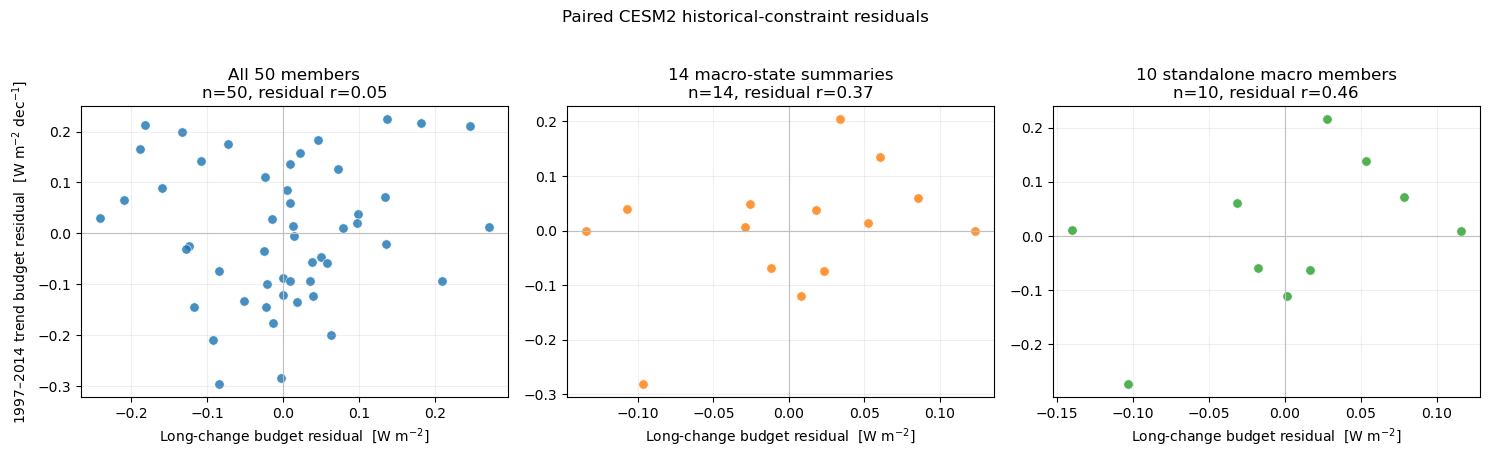

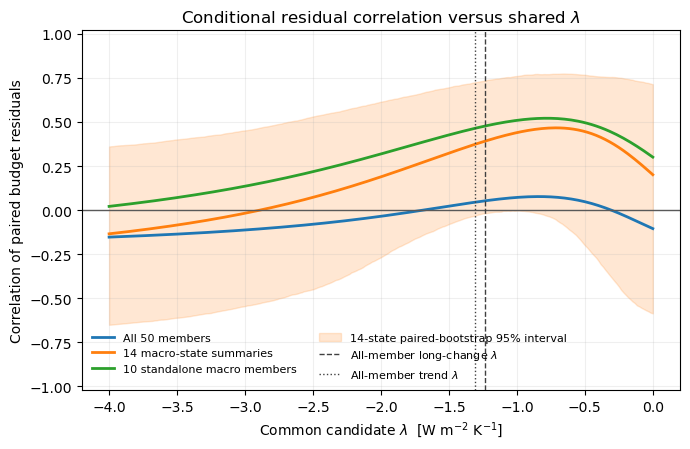

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.4))
for ax, (label, check, _, color) in zip(axes, independence_samples):
    residual_long = check["residual_long"]
    residual_trend = check["residual_trend"]
    rho = numpy_correlation(residual_long, residual_trend)
    ax.scatter(
        residual_long,
        residual_trend,
        s=46,
        alpha=0.82,
        color=color,
        edgecolor="white",
        linewidth=0.5,
    )
    ax.axhline(0.0, color="0.75", linewidth=0.8)
    ax.axvline(0.0, color="0.75", linewidth=0.8)
    ax.set_title(f"{label}\nn={residual_long.size}, residual r={rho:.2f}")
    ax.set_xlabel("Long-change budget residual  [W m$^{-2}$]")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("1997–2014 trend budget residual  [W m$^{-2}$ dec$^{-1}$]")
fig.suptitle("Paired CESM2 historical-constraint residuals", y=1.03)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.0, 4.6))
for label, _, _, color in independence_samples:
    ax.plot(
        CONDITIONAL_LAMBDA_GRID,
        conditional_rho_curves[label],
        color=color,
        linewidth=2.0,
        label=label,
    )
ax.fill_between(
    CONDITIONAL_LAMBDA_GRID,
    macro_rho_lower,
    macro_rho_upper,
    color="tab:orange",
    alpha=0.18,
    label="14-state paired-bootstrap 95% interval",
)
ax.axhline(0.0, color="0.35", linewidth=1.0)
ax.axvline(
    independence_all_members["lambda_long_forced"],
    color="0.25",
    linestyle="--",
    linewidth=1.0,
    label="All-member long-change $\lambda$",
)
ax.axvline(
    independence_all_members["lambda_trend_forced"],
    color="0.25",
    linestyle=":",
    linewidth=1.0,
    label="All-member trend $\lambda$",
)
ax.set(
    xlabel="Common candidate $\lambda$  [W m$^{-2}$ K$^{-1}$]",
    ylabel="Correlation of paired budget residuals",
    title="Conditional residual correlation versus shared $\lambda$",
    ylim=(-1.02, 1.02),
)
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

### Interpretation

A confidence interval containing zero does not establish independence. Treat the independent-likelihood approximation as defensible only if the residual correlation remains scientifically negligible across the relevant common-$\lambda$ range and setting the cross-covariance to zero has negligible effect on the eventual posterior. The 14-state result is the primary initialization-aware check, but it is approximate: each micro-cluster point averages 10 members whereas each standalone macro point contains one member, so the 14 points have unequal internal-variability precision. The all-50 and standalone-macro results should therefore be retained as sensitivities.

## CESM2 1pctCO2: feedback from rolling 18-year trends

Load the CMIP6 CESM2 `r1i1p1f1` 1pctCO2 simulation, calculate exact-area-weighted global annual means of incoming shortwave (`rsdt`), outgoing shortwave (`rsut`), outgoing longwave (`rlut`), and near-surface air temperature (`tas`), and form the standard net-downward TOA imbalance as $N=\mathrm{rsdt}-\mathrm{rlut}-\mathrm{rsut}$. The radiative response is then $R=N-F$. For a logarithmic CO$_2$ forcing, the annual ramp is $F(t)=F_{2\times}\,t\log(1.01)/\log(2)$, where experiment year 1 has $C/C_0=1.01$.

**Forcing and sign convention:** IPCC AR6 WGI Chapter 7, Table 7.2 gives CESM2 $F_{2\times}=4.48$ W m$^{-2}$ in the effective-radiative-forcing (ERF) column. The constructed $N=\mathrm{rsdt}-\mathrm{rlut}-\mathrm{rsut}$ is net-downward positive, so the ramp uses $F_{2\times,\downarrow}=+4.48$ W m$^{-2}$ in $R=N-F$. Equivalently, an upward-positive convention would store $F_{2\times,\uparrow}=-4.48$ W m$^{-2}$.

In [28]:
ONEPCT_ROOT = Path(
    "/glade/collections/cmip/CMIP6/CMIP/NCAR/CESM2/"
    "1pctCO2/r1i1p1f1/Amon"
)
ONEPCT_AREA_PATH = Path(
    "/glade/collections/cmip/CMIP6/CMIP/NCAR/CESM2/"
    "piControl/r1i1p1f1/fx/areacella/gn/latest/"
    "areacella_fx_CESM2_piControl_r1i1p1f1_gn.nc"
)
ONEPCT_VARIABLES = ("rsdt", "rlut", "rsut", "tas")


def load_onepctco2_global_annual(variable):
    """Load one CMIP6 field and return its area- and time-weighted annual mean."""
    paths = sorted((ONEPCT_ROOT / variable / "gn/latest").glob("*.nc"))
    if len(paths) != 3:
        raise FileNotFoundError(
            f"Expected three 50-year {variable} files; found {len(paths)}"
        )

    with xr.open_dataset(ONEPCT_AREA_PATH) as area_source:
        area = area_source["areacella"].load()
    assert area.notnull().all().item()

    with xr.open_mfdataset(
        paths,
        combine="by_coords",
        decode_times=TIME_DECODER,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": 120},
    ) as source:
        source_attrs = source[variable].attrs.copy()
        global_monthly = source[variable].weighted(area).mean(
            ("lat", "lon"), skipna=False
        )
        days = source.time.dt.days_in_month
        annual = (
            (global_monthly * days).groupby("time.year").sum()
            / days.groupby("time.year").sum()
        ).load()

    np.testing.assert_array_equal(annual.year.values, np.arange(1, 151))
    assert annual.notnull().all().item()
    annual = annual.rename(variable)
    annual.attrs = {
        **source_attrs,
        "long_name": f"Global annual mean {source_attrs.get('long_name', variable)}",
        "spatial_weighting": "CMIP6 areacella",
        "temporal_weighting": "calendar days per month",
    }
    return annual


onepctco2_annual_global = xr.Dataset(
    {variable: load_onepctco2_global_annual(variable)
     for variable in ONEPCT_VARIABLES}
)
onepctco2_annual_global.attrs = {
    "source": "CMIP6 CESM2 1pctCO2 r1i1p1f1",
    "experiment_years": "1-150",
}
onepctco2_annual_global


/glade/u/home/vcooper/miniconda3/envs/kant/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'areacella' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/glade/u/home/vcooper/miniconda3/envs/kant/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'rsdt' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/glade/u/home/vcooper/miniconda3/envs/kant/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'rsdt' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/glade/u/home/vcooper/miniconda3/envs/kant/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'rsdt' has multiple fill values {np.floa

<xarray.Dataset> Size: 6kB
Dimensions:  (year: 150)
Coordinates:
  * year     (year) int64 1kB 1 2 3 4 5 6 7 8 ... 144 145 146 147 148 149 150
Data variables:
    rsdt     (year) float64 1kB 340.2 340.2 340.2 340.2 ... 340.2 340.2 340.2
    rlut     (year) float64 1kB 240.1 240.2 240.4 240.2 ... 244.4 244.7 244.3
    rsut     (year) float64 1kB 99.26 98.21 99.63 99.19 ... 91.81 91.91 91.99
    tas      (year) float64 1kB 286.9 287.0 287.0 286.9 ... 293.1 293.1 293.0
Attributes:
    source:            CMIP6 CESM2 1pctCO2 r1i1p1f1
    experiment_years:  1-150

,R_trend,T_trend,lambda,window_start_year,window_end_year,window_midpoint_year
window,,,,,,
0,-0.0709,0.0296,-2.3928,1,19,10.0
1,-0.0673,0.0283,-2.3733,2,20,11.0
2,-0.0477,0.0290,-1.6454,3,21,12.0
3,-0.0484,0.0304,-1.5895,4,22,13.0
4,-0.0500,0.0315,-1.5863,5,23,14.0
127,-0.0191,0.0605,-0.3156,128,146,137.0
128,-0.0254,0.0638,-0.3977,129,147,138.0
129,-0.0357,0.0671,-0.5317,130,148,139.0
130,-0.0344,0.0661,-0.5205,131,149,140.0


,18-year lambda
count,132.000
mean,-1.216
std,0.481
min,-2.393
5%,-2.027
50%,-1.084
95%,-0.562
max,-0.316


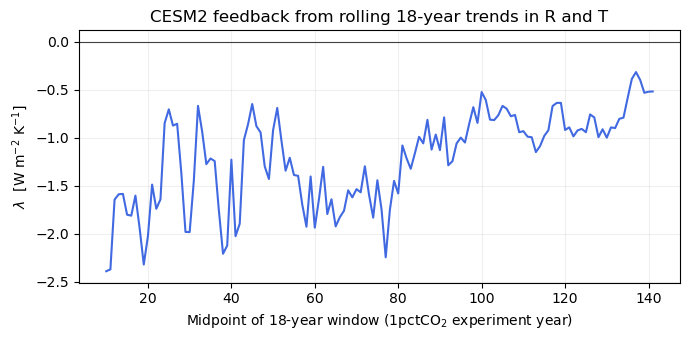

In [30]:
ONEPCT_WINDOW_YEARS = 19
ONEPCT_F2X_DOWN = 4.48  # W m-2; CESM2 ERF, IPCC AR6 WGI Table 7.2
ONEPCT_F2X_UP = -ONEPCT_F2X_DOWN

experiment_year = onepctco2_annual_global.year.astype(np.float64)
co2_ratio = 1.01 ** experiment_year
F_onepct = (
    ONEPCT_F2X_DOWN * np.log(co2_ratio) / np.log(2.0)
).rename("F")
N_onepct = (
    onepctco2_annual_global["rsdt"]
    - onepctco2_annual_global["rlut"]
    - onepctco2_annual_global["rsut"]
).rename("N")
T_onepct = onepctco2_annual_global["tas"].rename("T")
R_onepct = (N_onepct - F_onepct).rename("R")

N_onepct.attrs = {
    "long_name": "Net downward TOA radiation (rsdt - rlut - rsut)",
    "units": "W m-2",
    "positive": "down",
    "calculation": "rsdt - rlut - rsut",
}
F_onepct.attrs = {
    "long_name": "Idealized effective radiative forcing for the 1pctCO2 ramp",
    "units": "W m-2",
    "positive": "down",
    "calculation": "4.48 * year * log(1.01) / log(2)",
    "F2x_source": "IPCC AR6 WGI Chapter 7, Table 7.2",
}
R_onepct.attrs = {
    "long_name": "Radiative response (R = N - F)",
    "units": "W m-2",
    "sign_convention": "N = F + R = F + lambda*T; fluxes positive downward",
}
onepctco2_terms = xr.Dataset(
    {"N": N_onepct, "F": F_onepct, "R": R_onepct, "T": T_onepct}
)

window_start = np.arange(
    int(experiment_year.min()),
    int(experiment_year.max()) - ONEPCT_WINDOW_YEARS + 2,
)
window_end = window_start + ONEPCT_WINDOW_YEARS - 1
R_trend = np.empty(window_start.size)
T_trend = np.empty(window_start.size)

for i, (start, end) in enumerate(zip(window_start, window_end)):
    years = np.arange(start, end + 1)
    R_trend[i] = linear_time_slope(R_onepct, years).item()
    T_trend[i] = linear_time_slope(T_onepct, years).item()

if np.isclose(T_trend, 0.0).any():
    raise ZeroDivisionError("At least one 18-year T trend is zero")

onepctco2_feedback_18yr = xr.Dataset(
    data_vars={
        "R_trend": ("window", R_trend),
        "T_trend": ("window", T_trend),
        "lambda": ("window", R_trend / T_trend),
    },
    coords={
        "window": np.arange(window_start.size),
        "window_start_year": ("window", window_start),
        "window_end_year": ("window", window_end),
        "window_midpoint_year": (
            "window", (window_start + window_end) / 2
        ),
    },
)
onepctco2_feedback_18yr["R_trend"].attrs = {
    "long_name": "OLS trend in R over each 18-year window",
    "units": "W m-2 yr-1",
}
onepctco2_feedback_18yr["T_trend"].attrs = {
    "long_name": "OLS trend in T over each 18-year window",
    "units": "K yr-1",
}
onepctco2_feedback_18yr["lambda"].attrs = {
    "long_name": "Feedback from the ratio of 18-year OLS trends",
    "units": "W m-2 K-1",
    "calculation": "R_trend / T_trend",
}

feedback_18yr_table = onepctco2_feedback_18yr[["R_trend", "T_trend", "lambda"]].to_dataframe()
display(pd.concat([feedback_18yr_table.head(), feedback_18yr_table.tail()]).round(4))
display(feedback_18yr_table["lambda"].describe(
    percentiles=[0.05, 0.50, 0.95]
).to_frame("18-year lambda").round(3))

fig, ax = plt.subplots(figsize=(7.0, 3.5))
ax.axhline(0.0, color="0.25", linewidth=0.8)
ax.plot(
    onepctco2_feedback_18yr.window_midpoint_year,
    onepctco2_feedback_18yr["lambda"],
    color="royalblue",
    linewidth=1.5,
)
ax.set(
    xlabel="Midpoint of 18-year window (1pctCO$_2$ experiment year)",
    ylabel="$\lambda$  [W m$^{-2}$ K$^{-1}$]",
    title="CESM2 feedback from rolling 18-year trends in R and T",
)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


## GFDL-ESM4 and MPI-ESM1-2-HR 1pctCO2 comparison

Repeat the CESM2 rolling-trend calculation for CMIP6 `r1i1p1f1` from GFDL-ESM4 and MPI-ESM1-2-HR. Each window contains **19 annual means**, matching 2006–2024 and spanning 18 years between its endpoints. All models are restricted to the first 150 experiment years. MPI's source dates are 1850–2014, so its first 150 source years (1850–1999) are mapped positionally to experiment years 1–150 before constructing the CO$_2$ forcing.

The forcing ramp uses model-specific ERF values from [IPCC AR6 WGI Chapter 7, Table 7.2](https://www.ipcc.ch/report/ar6/wg1/chapter/chapter-7/): **4.48 W m$^{-2}$ for CESM2, 3.85 W m$^{-2}$ for GFDL-ESM4, and 4.20 W m$^{-2}$ for MPI-ESM1-2-HR**. AR6 reports 4.20 W m$^{-2}$ for MPI-ESM1-2-LR; following the requested assumption, that value is also used for HR. These Table 7.2 ERFs are based on the CMIP6 $4\times\mathrm{CO}_2$ experiments scaled by 0.476. The local NCAR mirror lacks the three MPI TOA fluxes, so the helper stages them once from the official [MPI-ESM1-2-HR 1pctCO2 ESGF dataset](https://doi.org/10.22033/ESGF/CMIP6.6434) when they are not already cached.

These rolling ratios are diagnostics, not independent feedback samples: adjacent windows overlap in 18 of 19 years, and each model has only one realization. Their spread mixes forced feedback evolution, internal variability, control drift, forcing uncertainty, and sensitivity to small temperature-trend denominators.

In [31]:
import hashlib
import json
import shutil
import urllib.parse
import urllib.request

ONEPCT_MODEL_ORDER = ("CESM2", "GFDL-ESM4", "MPI-ESM1-2-HR")
ONEPCT_EXPERIMENT_YEARS = np.arange(1, 151)
ONEPCT_ROLLING_POINTS = ONEPCT_WINDOW_YEARS
ONEPCT_ROLLING_SPAN_YEARS = ONEPCT_ROLLING_POINTS - 1
assert ONEPCT_ROLLING_POINTS == 19
assert ONEPCT_ROLLING_SPAN_YEARS == 18

ONEPCT_ADDITIONAL_CONFIG = {
    "GFDL-ESM4": {
        "root": Path(
            "/glade/collections/cmip/CMIP6/CMIP/NOAA-GFDL/"
            "GFDL-ESM4/1pctCO2/r1i1p1f1"
        ),
        "grid": "gr1",
        "version": "v20180701",
        "calendar": "noleap",
        "source_years": np.arange(1, 151),
        "area": Path(
            "/glade/collections/cmip/CMIP6/CMIP/NOAA-GFDL/"
            "GFDL-ESM4/1pctCO2/r1i1p1f1/fx/areacella/gr1/"
            "v20180701/areacella/"
            "areacella_fx_GFDL-ESM4_1pctCO2_r1i1p1f1_gr1.nc"
        ),
    },
    "MPI-ESM1-2-HR": {
        "root": Path(
            "/glade/collections/cmip/CMIP6/CMIP/MPI-M/"
            "MPI-ESM1-2-HR/1pctCO2/r1i1p1f1"
        ),
        "grid": "gn",
        "version": "v20190710",
        "calendar": "proleptic_gregorian",
        "source_years": np.arange(1850, 2000),
        "area": Path(
            "/glade/collections/cmip/CMIP6/CMIP/MPI-M/"
            "MPI-ESM1-2-HR/1pctCO2/r1i1p1f1/fx/areacella/gn/"
            "v20190710/areacella/"
            "areacella_fx_MPI-ESM1-2-HR_1pctCO2_r1i1p1f1_gn.nc"
        ),
        "remote_cache": Path(
            "/glade/derecho/scratch/vcooper/tmp/mmlea_mpi_1pctco2"
        ),
    },
}

IPCC_AR6_CH7_URL = (
    "https://www.ipcc.ch/report/ar6/wg1/chapter/chapter-7/"
)
IPCC_AR6_F2X_ERF = {
    "CESM2": 4.48,
    "GFDL-ESM4": 3.85,
    # AR6 Table 7.2 reports MPI-ESM1-2-LR; assume the same ERF for HR.
    "MPI-ESM1-2-HR": 4.20,
}
assert tuple(IPCC_AR6_F2X_ERF) == ONEPCT_MODEL_ORDER
assert np.isclose(ONEPCT_F2X_DOWN, IPCC_AR6_F2X_ERF["CESM2"])

ZELINKA_FEEDBACK_PATH = Path(
    "/glade/u/home/vcooper/work/hist_sst/data/zelinka_cmip/"
    "cmip56_forcing_feedback_ecs.json"
)
with ZELINKA_FEEDBACK_PATH.open() as feedback_source:
    zelinka_feedback_data = json.load(feedback_source)["CMIP6"]

onepctco2_f2x = xr.DataArray(
    [
        IPCC_AR6_F2X_ERF[model]
        for model in ONEPCT_MODEL_ORDER
    ],
    dims="model",
    coords={"model": np.asarray(ONEPCT_MODEL_ORDER)},
    name="F2x",
    attrs={
        "long_name": "IPCC AR6 effective 2xCO2 radiative forcing",
        "units": "W m-2",
        "positive": "down",
        "source": "IPCC AR6 WGI Chapter 7, Table 7.2",
        "source_url": IPCC_AR6_CH7_URL,
        "method": "ERF from 4xCO2 experiments scaled by 0.476",
        "MPI-ESM1-2-HR_assumption": "Uses the reported MPI-ESM1-2-LR value",
    },
)
onepctco2_gregory_net = xr.DataArray(
    [
        zelinka_feedback_data[model]["r1i1p1f1"]["NET"]
        for model in ONEPCT_MODEL_ORDER
    ],
    dims="model",
    coords={"model": np.asarray(ONEPCT_MODEL_ORDER)},
    name="gregory_net_feedback",
    attrs={
        "units": "W m-2 K-1",
        "source": str(ZELINKA_FEEDBACK_PATH),
    },
)
assert (onepctco2_f2x > 0).all().item()

ESGF_SEARCH_ENDPOINT = "https://esgf-node.ornl.gov/proxy/search"
MPI_REMOTE_FLUXES = ("rsdt", "rsut", "rlut")
MPI_EXPECTED_FILES_PER_VARIABLE = 33


def stage_mpi_onepctco2_flux(variable):
    """Cache one missing MPI field from the official ESGF replica."""
    if variable not in MPI_REMOTE_FLUXES:
        raise ValueError(f"Unexpected MPI remote variable: {variable}")

    target_directory = (
        ONEPCT_ADDITIONAL_CONFIG["MPI-ESM1-2-HR"]["remote_cache"]
        / variable
    )
    target_directory.mkdir(parents=True, exist_ok=True)
    cached = sorted(target_directory.glob("*.nc"))
    if (
        len(cached) == MPI_EXPECTED_FILES_PER_VARIABLE
        and all(path.stat().st_size > 0 for path in cached)
    ):
        return cached

    parameters = {
        "project": "CMIP6",
        "type": "File",
        "activity_id": "CMIP",
        "source_id": "MPI-ESM1-2-HR",
        "experiment_id": "1pctCO2",
        "variant_label": "r1i1p1f1",
        "table_id": "Amon",
        "variable_id": variable,
        "grid_label": "gn",
        "data_node": "esgf-node.ornl.gov",
        "format": "application/solr+json",
        "limit": 100,
        "latest": "true",
        "query": "*",
    }
    search_url = (
        f"{ESGF_SEARCH_ENDPOINT}?{urllib.parse.urlencode(parameters)}"
    )
    with urllib.request.urlopen(search_url, timeout=120) as response:
        documents = json.load(response)["response"]["docs"]
    assert len(documents) == MPI_EXPECTED_FILES_PER_VARIABLE

    staged = []
    for document in tqdm(sorted(documents, key=lambda item: item["title"]),
                         desc=f"ESGF MPI {variable}"):
        destination = target_directory / document["title"]
        expected_size = int(document["size"])
        if destination.exists() and destination.stat().st_size == expected_size:
            staged.append(destination)
            continue

        http_urls = [
            item.split("|")[0]
            for item in document["url"]
            if item.endswith("|HTTPServer")
        ]
        if len(http_urls) != 1:
            raise ValueError(f"Expected one HTTP URL for {destination.name}")
        download_url = http_urls[0].replace("http://", "https://", 1)
        partial = destination.with_suffix(".nc.part")
        with (
            urllib.request.urlopen(download_url, timeout=300) as remote,
            partial.open("wb") as local,
        ):
            shutil.copyfileobj(remote, local, length=1024 * 1024)
        if partial.stat().st_size != expected_size:
            raise IOError(f"Incomplete ESGF download: {destination.name}")

        algorithm = document["checksum_type"][0].lower().replace("-", "")
        digest = hashlib.new(algorithm)
        with partial.open("rb") as downloaded:
            for block in iter(lambda: downloaded.read(1024 * 1024), b""):
                digest.update(block)
        if digest.hexdigest() != document["checksum"][0].lower():
            raise IOError(f"Checksum mismatch: {destination.name}")
        partial.replace(destination)
        staged.append(destination)

    assert len(staged) == MPI_EXPECTED_FILES_PER_VARIABLE
    return staged


pd.DataFrame(
    {
        "AR6_ERF_F2x_Wm-2": onepctco2_f2x.values,
        "abrupt4x_NET_Wm-2_K-1": onepctco2_gregory_net.values,
    },
    index=ONEPCT_MODEL_ORDER,
).round(3)


,AR6_ERF_F2x_Wm-2,abrupt4x_NET_Wm-2_K-1
CESM2,4.48,-0.634
GFDL-ESM4,3.85,-1.423
MPI-ESM1-2-HR,4.20,-1.224


3.645808842696683

In [32]:
def onepctco2_paths(model, variable):
    config = ONEPCT_ADDITIONAL_CONFIG[model]
    local_directory = (
        config["root"] / "Amon" / variable
        / config["grid"] / config["version"]
    )
    paths = sorted(local_directory.rglob("*.nc"))
    if not paths and model == "MPI-ESM1-2-HR" and variable in MPI_REMOTE_FLUXES:
        paths = stage_mpi_onepctco2_flux(variable)
    if not paths:
        raise FileNotFoundError(f"No {model} {variable} files under {local_directory}")
    return paths


def load_cmip_onepctco2_global_annual(model, variable):
    """Stream files and return the first 150 exact-area annual means."""
    config = ONEPCT_ADDITIONAL_CONFIG[model]
    paths = onepctco2_paths(model, variable)
    with xr.open_dataset(config["area"]) as area_source:
        base_area = area_source["areacella"].load()
    assert np.isfinite(base_area.values).all()
    assert (base_area > 0).all().item()
    assert 4.5e14 < base_area.sum().item() < 5.5e14

    monthly_parts = []
    calendars = set()
    source_attrs = None
    for path in paths:
        with xr.open_dataset(
            path, decode_times=TIME_DECODER, chunks={"time": 12}
        ) as source:
            field = source[variable]
            if source_attrs is None:
                source_attrs = field.attrs.copy()
            calendars.add(source.time.encoding.get("calendar"))

            # MPI latitude labels differ from areacella only at ~1e-14 deg.
            # Validate positionally, then make labels exact before weighting;
            # otherwise xarray silently drops non-bitwise-equal latitude rows.
            for dimension in ("lat", "lon"):
                assert base_area.sizes[dimension] == field.sizes[dimension]
                np.testing.assert_allclose(
                    base_area[dimension].values,
                    field[dimension].values,
                    rtol=0.0,
                    atol=1e-10,
                )
            aligned_area = base_area.assign_coords(
                lat=field.lat.values, lon=field.lon.values
            )
            field, aligned_area = xr.align(field, aligned_area, join="exact")
            global_month = field.weighted(aligned_area).mean(
                ("lat", "lon"), skipna=False
            ).load()
            monthly_parts.append(global_month)

    assert calendars == {config["calendar"]}, calendars
    monthly = xr.concat(monthly_parts, dim="time").sortby("time")
    assert monthly.indexes["time"].is_unique
    assert monthly.notnull().all().item()

    days = monthly.time.dt.days_in_month
    source_year = monthly.time.dt.year.rename("source_year")
    months_per_year = xr.ones_like(days, dtype=np.int16).groupby(source_year).sum()
    assert (months_per_year == 12).all().item()
    annual = (
        (monthly * days).groupby(source_year).sum()
        / days.groupby(source_year).sum()
    )
    selected_source_years = annual.source_year.values[:150]
    np.testing.assert_array_equal(selected_source_years, config["source_years"])
    annual = (
        annual.isel(source_year=slice(0, 150))
        .rename({"source_year": "year"})
        .assign_coords(year=ONEPCT_EXPERIMENT_YEARS)
        .rename(variable)
    )
    annual.attrs = {
        **source_attrs,
        "long_name": f"Global annual mean {source_attrs.get('long_name', variable)}",
        "spatial_weighting": "CMIP6 areacella after guarded coordinate alignment",
        "temporal_weighting": "calendar days per month",
        "source_years_used": (
            f"{selected_source_years[0]}-{selected_source_years[-1]}"
        ),
    }
    return annual


additional_model_datasets = []
for model in tqdm(ONEPCT_MODEL_ORDER[1:], desc="Additional 1pctCO2 models"):
    model_data = xr.Dataset(
        {
            variable: load_cmip_onepctco2_global_annual(model, variable)
            for variable in ONEPCT_VARIABLES
        }
    ).expand_dims(model=[model])
    additional_model_datasets.append(model_data)

cesm_onepctco2 = (
    onepctco2_annual_global.sel(year=ONEPCT_EXPERIMENT_YEARS)
    .expand_dims(model=["CESM2"])
)
onepctco2_annual_by_model = xr.concat(
    [cesm_onepctco2, *additional_model_datasets],
    dim="model",
    join="exact",
    combine_attrs="drop_conflicts",
).assign_coords(
    source_calendar_year=(
        ("model", "year"),
        np.vstack(
            [
                ONEPCT_EXPERIMENT_YEARS,
                ONEPCT_ADDITIONAL_CONFIG["GFDL-ESM4"]["source_years"],
                ONEPCT_ADDITIONAL_CONFIG["MPI-ESM1-2-HR"]["source_years"],
            ]
        ),
    )
)
np.testing.assert_array_equal(
    onepctco2_annual_by_model.model.values, ONEPCT_MODEL_ORDER
)
assert onepctco2_annual_by_model.sizes == {"model": 3, "year": 150}
assert onepctco2_annual_by_model.to_array().notnull().all().item()
mean_incoming_solar = onepctco2_annual_by_model["rsdt"].mean("year")
assert ((mean_incoming_solar > 335) & (mean_incoming_solar < 345)).all().item()
first_year_N = (
    onepctco2_annual_by_model["rsdt"]
    - onepctco2_annual_by_model["rsut"]
    - onepctco2_annual_by_model["rlut"]
).isel(year=0)
assert (np.abs(first_year_N) < 5).all().item()

onepctco2_annual_by_model


Additional 1pctCO2 models:   0%|          | 0/2 [00:00<?, ?it/s]

<xarray.Dataset> Size: 19kB
Dimensions:               (model: 3, year: 150)
Coordinates:
  * model                 (model) object 24B 'CESM2' 'GFDL-ESM4' 'MPI-ESM1-2-HR'
  * year                  (year) int64 1kB 1 2 3 4 5 6 ... 146 147 148 149 150
    height                float64 8B 2.0
    source_calendar_year  (model, year) int64 4kB 1 2 3 4 ... 1997 1998 1999
Data variables:
    rsdt                  (model, year) float64 4kB 340.2 340.2 ... 340.2 340.2
    rlut                  (model, year) float64 4kB 240.1 240.2 ... 241.1 241.0
    rsut                  (model, year) float64 4kB 99.26 98.21 ... 96.66 96.54
    tas                   (model, year) float64 4kB 286.9 287.0 ... 291.6 291.7
Attributes:
    source:            CMIP6 CESM2 1pctCO2 r1i1p1f1
    experiment_years:  1-150

In [ ]:
# The corrected multimodel dataset is constructed and displayed below.

In [33]:
onepct_experiment_year = onepctco2_annual_by_model.year.astype(np.float64)
onepct_forcing_factor = np.log(1.01) / np.log(2.0)
F_onepct_by_model = (
    onepctco2_f2x * onepct_forcing_factor * onepct_experiment_year
).transpose("model", "year").rename("F")
N_onepct_by_model = (
    onepctco2_annual_by_model["rsdt"]
    - onepctco2_annual_by_model["rsut"]
    - onepctco2_annual_by_model["rlut"]
).rename("N")
T_onepct_by_model = onepctco2_annual_by_model["tas"].rename("T")
R_onepct_by_model = (N_onepct_by_model - F_onepct_by_model).rename("R")

multi_window_start = np.arange(
    1, 150 - ONEPCT_ROLLING_POINTS + 2
)
multi_window_end = multi_window_start + ONEPCT_ROLLING_POINTS - 1
assert multi_window_start.size == 132
assert np.all(multi_window_end - multi_window_start == 18)
window_index = xr.IndexVariable("window", np.arange(multi_window_start.size))


def rolling_onepctco2_slopes(data):
    return xr.concat(
        [
            linear_time_slope(data, np.arange(start, end + 1))
            for start, end in zip(multi_window_start, multi_window_end)
        ],
        dim=window_index,
    ).transpose("model", "window")


multi_N_trend = rolling_onepctco2_slopes(N_onepct_by_model).rename("N_trend")
multi_F_trend = rolling_onepctco2_slopes(F_onepct_by_model).rename("F_trend")
multi_R_trend = rolling_onepctco2_slopes(R_onepct_by_model).rename("R_trend")
multi_T_trend = rolling_onepctco2_slopes(T_onepct_by_model).rename("T_trend")
if np.isclose(multi_T_trend, 0.0).any().item():
    raise ZeroDivisionError("At least one rolling temperature trend is zero")
multi_lambda = (multi_R_trend / multi_T_trend).rename("lambda")
multi_lambda_f2x_sensitivity = (
    -onepct_forcing_factor / multi_T_trend
).rename("dlambda_dF2x")
onepctco2_feedback_multimodel = xr.Dataset(
    {
        "N_trend": multi_N_trend,
        "F_trend": multi_F_trend,
        "R_trend": multi_R_trend,
        "T_trend": multi_T_trend,
        "lambda": multi_lambda,
        "dlambda_dF2x": multi_lambda_f2x_sensitivity,
        "F2x": onepctco2_f2x,
        "gregory_net_feedback": onepctco2_gregory_net,
    },
    coords={
        "window_start_year": ("window", multi_window_start),
        "window_end_year": ("window", multi_window_end),
        "window_midpoint_year": (
            "window", (multi_window_start + multi_window_end) / 2
        ),
    },
)
onepctco2_feedback_multimodel.attrs = {
    "description": "Rolling 19-point trend-ratio feedbacks over an 18-year endpoint span",
    "forcing": "Model-specific ERF2x from IPCC AR6 WGI Chapter 7, Table 7.2",
    "sign_convention": "N = F + R = F + lambda*T; fluxes positive downward",
    "years_used": "First 150 1pctCO2 experiment years",
}
for variable in ("N_trend", "F_trend", "R_trend"):
    onepctco2_feedback_multimodel[variable].attrs["units"] = "W m-2 yr-1"
onepctco2_feedback_multimodel["T_trend"].attrs["units"] = "K yr-1"
onepctco2_feedback_multimodel["lambda"].attrs["units"] = "W m-2 K-1"
onepctco2_feedback_multimodel["dlambda_dF2x"].attrs = {
    "long_name": "Sensitivity of rolling lambda to assumed F2x",
    "units": "K-1",
}
np.testing.assert_allclose(
    multi_R_trend.values,
    (multi_N_trend - multi_F_trend).values,
    rtol=1e-12,
    atol=1e-12,
)
assert onepctco2_feedback_multimodel.to_array().notnull().all().item()


def summarize_lambda_variation(variable):
    rows = []
    for model in ONEPCT_MODEL_ORDER:
        values = onepctco2_feedback_multimodel[variable].sel(model=model)
        quantiles = values.quantile([0.05, 0.25, 0.50, 0.75, 0.95])
        rows.append(
            {
                "model": model,
                "F2x_Wm-2": float(
                    onepctco2_feedback_multimodel["F2x"].sel(model=model)
                ),
                "windows": values.size,
                "first": float(values.isel(window=0)),
                "last": float(values.isel(window=-1)),
                "last_minus_first": float(
                    values.isel(window=-1) - values.isel(window=0)
                ),
                "minimum": float(values.min()),
                "q05": float(quantiles.sel(quantile=0.05)),
                "median": float(quantiles.sel(quantile=0.50)),
                "q95": float(quantiles.sel(quantile=0.95)),
                "maximum": float(values.max()),
                "full_range": float(values.max() - values.min()),
                "q05_q95_width": float(
                    quantiles.sel(quantile=0.95)
                    - quantiles.sel(quantile=0.05)
                ),
                "IQR": float(
                    quantiles.sel(quantile=0.75)
                    - quantiles.sel(quantile=0.25)
                ),
            }
        )
    return pd.DataFrame(rows).set_index("model")


onepctco2_lambda_variation = summarize_lambda_variation("lambda")
onepctco2_lambda_variation["min_Ttrend_K_yr-1"] = (
    onepctco2_feedback_multimodel["T_trend"].min("window").to_series()
)
onepctco2_lambda_variation["max_abs_dlambda_dF2x_K-1"] = (
    np.abs(onepctco2_feedback_multimodel["dlambda_dF2x"])
    .max("window")
    .to_series()
)

display(onepctco2_lambda_variation.round(3))


,F2x_Wm-2,windows,first,last,last_minus_first,minimum,q05,median,q95,maximum,full_range,q05_q95_width,IQR,min_Ttrend_K_yr-1,max_abs_dlambda_dF2x_K-1
model,,,,,,,,,,,,,,,
CESM2,4.48,132,-2.393,-0.518,1.875,-2.393,-2.027,-1.084,-0.562,-0.316,2.077,1.465,0.734,0.023,0.630
GFDL-ESM4,3.85,132,-1.769,-0.973,0.796,-3.774,-3.018,-1.397,-0.932,-0.570,3.204,2.087,0.609,0.012,1.232
MPI-ESM1-2-HR,4.20,132,-2.161,-0.806,1.355,-4.556,-2.502,-1.383,-0.964,-0.806,3.750,1.538,0.528,0.011,1.251


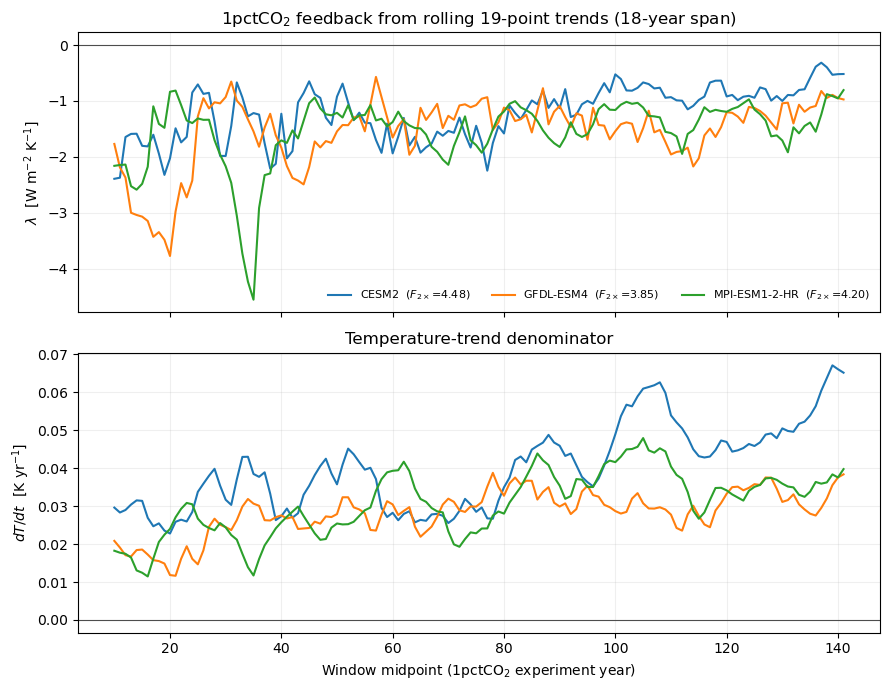

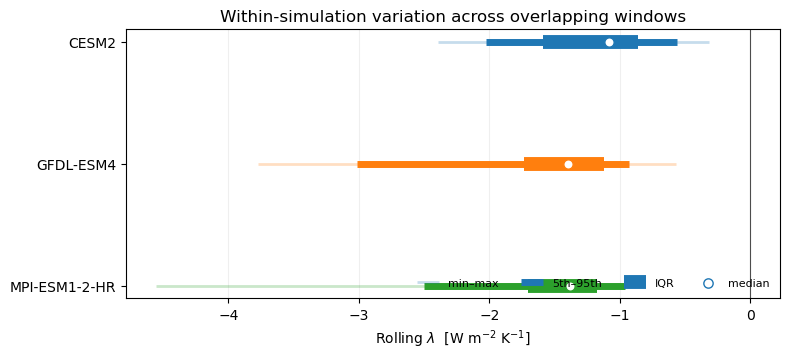

In [34]:
ONEPCT_MODEL_COLORS = {
    "CESM2": "tab:blue",
    "GFDL-ESM4": "tab:orange",
    "MPI-ESM1-2-HR": "tab:green",
}

fig, axes = plt.subplots(2, 1, figsize=(9.0, 7.0), sharex=True)
for model in ONEPCT_MODEL_ORDER:
    feedback = onepctco2_feedback_multimodel.sel(model=model)
    forcing_value = float(feedback["F2x"])
    axes[0].plot(
        feedback.window_midpoint_year,
        feedback["lambda"],
        color=ONEPCT_MODEL_COLORS[model],
        linewidth=1.5,
        label=rf"{model}  ($F_{{2\times}}$={forcing_value:.2f})",
    )
    axes[1].plot(
        feedback.window_midpoint_year,
        feedback["T_trend"],
        color=ONEPCT_MODEL_COLORS[model],
        linewidth=1.5,
        label=model,
    )
axes[0].axhline(0.0, color="0.3", linewidth=0.8)
axes[0].set_ylabel("$\lambda$  [W m$^{-2}$ K$^{-1}$]")
axes[0].set_title(
    "1pctCO$_2$ feedback from rolling 19-point trends (18-year span)"
)
axes[0].legend(frameon=False, ncol=3, fontsize=8)
axes[1].axhline(0.0, color="0.3", linewidth=0.8)
axes[1].set(
    xlabel="Window midpoint (1pctCO$_2$ experiment year)",
    ylabel="$dT/dt$  [K yr$^{-1}$]",
    title="Temperature-trend denominator",
)
for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.0, 3.7))
positions = np.arange(len(ONEPCT_MODEL_ORDER))
for position, model in zip(positions, ONEPCT_MODEL_ORDER):
    values = onepctco2_feedback_multimodel["lambda"].sel(model=model)
    q05, q25, median, q75, q95 = values.quantile(
        [0.05, 0.25, 0.50, 0.75, 0.95]
    ).values
    color = ONEPCT_MODEL_COLORS[model]
    ax.hlines(
        position, values.min(), values.max(), color=color, alpha=0.25,
        linewidth=2, label="min–max" if position == 0 else None,
    )
    ax.hlines(
        position, q05, q95, color=color, linewidth=5,
        label="5th–95th" if position == 0 else None,
    )
    ax.hlines(
        position, q25, q75, color=color, linewidth=10,
        label="IQR" if position == 0 else None,
    )
    ax.scatter(
        median, position, color="white", edgecolor=color, s=45, zorder=3,
        label="median" if position == 0 else None,
    )
ax.axvline(0.0, color="0.3", linewidth=0.8)
ax.set(
    yticks=positions,
    yticklabels=ONEPCT_MODEL_ORDER,
    xlabel="Rolling $\lambda$  [W m$^{-2}$ K$^{-1}$]",
    title="Within-simulation variation across overlapping windows",
)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.2)
ax.legend(frameon=False, ncol=4, fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()


### What varies, and by how much?

Conditional on the model-specific IPCC AR6 ERF values, the median rolling $\lambda$ is **−1.08** for CESM2, **−1.40** for GFDL-ESM4, and **−1.38 W m$^{-2}$ K$^{-1}$** for MPI-ESM1-2-HR. The 5th–95th percentile widths are **1.47**, **2.09**, and **1.54 W m$^{-2}$ K$^{-1}$**, respectively; the full min–max ranges are **2.08**, **3.20**, and **3.75 W m$^{-2}$ K$^{-1}$**. The interquartile ranges are **0.73**, **0.61**, and **0.53 W m$^{-2}$ K$^{-1}$**.

The first-to-last rolling estimates become less negative by about **1.88** (CESM2), **0.80** (GFDL-ESM4), and **1.36 W m$^{-2}$ K$^{-1}$** (MPI-ESM1-2-HR). This is not a clean estimate of pattern-effect evolution: the GFDL and MPI extremes coincide with temperature trends near 0.012 K yr$^{-1}$, making the ratio noisy. The full ranges should therefore not be interpreted as uncertainty intervals or as 132 independent realizations; the 5th–95th widths and the displayed numerator/denominator diagnostics are more informative.

Finally, the forcing choice matters materially. The maximum $|\partial\lambda/\partial F_{2\times}|$ is approximately 0.63, 1.23, and 1.25 K$^{-1}$ for CESM2, GFDL, and MPI. Thus even a 0.5 W m$^{-2}$ forcing difference can move an individual rolling estimate by roughly 0.3–0.6 W m$^{-2}$ K$^{-1}$. The analysis now uses only the model-specific AR6 ERFs; the obsolete common-forcing sensitivity has been removed.